In [2]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ipynb.fs.defs.competition1 import create_sparse_matrix, compute_stats

In [3]:
file = "data/train.csv"
df = pd.read_csv(file, header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [4]:
y = df["rating"]
x = df.drop(columns="rating")
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

## First Model

In [ ]:
class PMF:
    """
    PMF con Huber loss como objetivo (más cercano a MAE que MSE,
    y diferenciable en todo su dominio a diferencia del MAE puro).

    Huber(e, δ) = { 0.5 * e²          si |e| ≤ δ
                  { δ * (|e| - 0.5*δ)  si |e| > δ

    Con δ → 0 converge a MAE; con δ → ∞ converge a MSE.
    δ = 1.0 es un buen punto de partida para ratings 1-10.
    """

    def __init__(self, n_factors=10, lambda_U=0.01, lambda_V=0.01,
                 lr=0.001, n_epochs=100, batch_size=1024,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='adam', huber_delta=1.0, log_every=1):
        self.n_factors    = n_factors
        self.lambda_U     = lambda_U
        self.lambda_V     = lambda_V
        self.lr           = lr
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.clip_min     = clip_min
        self.clip_max     = clip_max
        self.random_state = random_state
        self.optimizer    = optimizer
        self.huber_delta  = huber_delta   # δ del Huber loss, con esto se controla a partir de que error pasa de ser quadrática a lineal la penalización
        self.log_every    = log_every     # imprimir log cada N épocas

        self.U = self.V = None
        self.history = []   # lista de dicts con métricas por época

    # ── Inicialización ────────────────────────────────────────────────────────
    def _init_factors(self, n_users, n_items):
        rng   = np.random.default_rng(self.random_state)
        scale = 1 / np.sqrt(self.n_factors)
        self.U = rng.normal(0, scale, (n_users, self.n_factors))
        self.V = rng.normal(0, scale, (n_items, self.n_factors))

        if self.optimizer == 'adam':
            self.mU = np.zeros_like(self.U); self.vU = np.zeros_like(self.U)
            self.mV = np.zeros_like(self.V); self.vV = np.zeros_like(self.V)
            self._adam_t = 0

    # ── Huber loss & gradiente ────────────────────────────────────────────────
    def _huber_loss_and_grad(self, errors):
        """
        Devuelve (loss_media, pseudo-gradiente respecto a la predicción).
        grad = -dL/d(pred) = dL/d(error) con signo para el update.
        """
        d    = self.huber_delta
        abs_e = np.abs(errors)
        mask  = abs_e <= d

        loss  = np.where(mask, 0.5 * errors ** 2, d * (abs_e - 0.5 * d))
        # dHuber/d(error)
        dgrad = np.where(mask, errors, d * np.sign(errors))

        return loss.mean(), dgrad   # grad wrt error; update usa -dgrad

    # ── Métricas de evaluación ────────────────────────────────────────────────
    def _metrics(self, user_idx, item_idx, ratings):
        preds  = np.clip(
            np.sum(self.U[user_idx] * self.V[item_idx], axis=1),
            self.clip_min, self.clip_max
        )
        errors = ratings - preds
        _, dgrad = self._huber_loss_and_grad(errors)
        huber = np.where(
            np.abs(errors) <= self.huber_delta,
            0.5 * errors ** 2,
            self.huber_delta * (np.abs(errors) - 0.5 * self.huber_delta)
        ).mean()
        mae   = np.mean(np.abs(errors))
        rmse  = np.sqrt(np.mean(errors ** 2))
        return {'huber': huber, 'mae': mae, 'rmse': rmse}

    # ── Adam update ───────────────────────────────────────────────────────────
    def _adam_update(self, param, m, v, grad, beta1=0.9, beta2=0.999, eps=1e-8):
        self._adam_t += 1
        m[:] = beta1 * m + (1 - beta1) * grad
        v[:] = beta2 * v + (1 - beta2) * grad ** 2
        m_hat = m / (1 - beta1 ** self._adam_t)
        v_hat = v / (1 - beta2 ** self._adam_t)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    def fit(self, x_train, y_train, x_val, y_val,
            user_map, item_map, patience=10):

        train_users = x_train['user'].map(user_map).values
        train_items = x_train['item'].map(item_map).values
        train_r     = y_train.values.astype(np.float64)

        val_mask  = x_val['user'].isin(user_map) & x_val['item'].isin(item_map)
        val_users = x_val.loc[val_mask, 'user'].map(user_map).values
        val_items = x_val.loc[val_mask, 'item'].map(item_map).values
        val_r     = y_val[val_mask].values.astype(np.float64)

        n_users, n_items = len(user_map), len(item_map)
        self._init_factors(n_users, n_items)

        n_samples  = len(train_r)
        rng        = np.random.default_rng(self.random_state)
        best_val   = np.inf
        best_U, best_V = self.U.copy(), self.V.copy()
        no_improve = 0

        print(f"{'Epoch':>6}  {'Train Huber':>12}  {'Train MAE':>10}  {'Train RMSE':>11}  "
              f"{'Val Huber':>10}  {'Val MAE':>8}  {'Val RMSE':>9}  {'Status':>12}")
        print("-" * 95)

        for epoch in range(self.n_epochs):
            perm   = rng.permutation(n_samples)
            u_shuf = train_users[perm]
            i_shuf = train_items[perm]
            r_shuf = train_r[perm]

            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                u_b = u_shuf[start:end]
                i_b = i_shuf[start:end]
                r_b = r_shuf[start:end]

                U_b    = self.U[u_b]
                V_b    = self.V[i_b]
                errors = r_b - np.sum(U_b * V_b, axis=1)

                # Gradiente del Huber respecto al error → -dL/d(pred)
                _, dgrad = self._huber_loss_and_grad(errors)

                # dL/dU = -dgrad * V  +  lambda * U  (regla cadena)
                grad_U = -dgrad[:, None] * V_b + self.lambda_U * U_b
                grad_V = -dgrad[:, None] * U_b + self.lambda_V * V_b

                if self.optimizer == 'adam':
                    for idx in np.unique(u_b):
                        mask = u_b == idx
                        self._adam_update(
                            self.U[idx], self.mU[idx], self.vU[idx],
                            grad_U[mask].mean(axis=0)
                        )
                    for idx in np.unique(i_b):
                        mask = i_b == idx
                        self._adam_update(
                            self.V[idx], self.mV[idx], self.vV[idx],
                            grad_V[mask].mean(axis=0)
                        )
                else:
                    for idx in np.unique(u_b):
                        self.U[idx] -= self.lr * grad_U[u_b == idx].mean(axis=0)
                    for idx in np.unique(i_b):
                        self.V[idx] -= self.lr * grad_V[i_b == idx].mean(axis=0)

            # ── Métricas ──────────────────────────────────────────────────────
            tr = self._metrics(train_users, train_items, train_r)
            vl = self._metrics(val_users,   val_items,   val_r)

            status = ''
            if vl['mae'] < best_val:
                best_val       = vl['mae']
                best_U, best_V = self.U.copy(), self.V.copy()
                no_improve     = 0
                status         = '✔ best'
            else:
                no_improve += 1
                status = f'no imp {no_improve}/{patience}'
                if no_improve >= patience:
                    self.history.append({'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()},
                                         **{f'val_{k}': v for k, v in vl.items()}})
                    print(f"{epoch+1:>6}  {tr['huber']:>12.4f}  {tr['mae']:>10.4f}  {tr['rmse']:>11.4f}  "
                          f"{vl['huber']:>10.4f}  {vl['mae']:>8.4f}  {vl['rmse']:>9.4f}  "
                          f"{'early stop':>12}")
                    print(f"\nEarly stopping época {epoch+1}  |  best val MAE: {best_val:.4f}")
                    break

            self.history.append({
                'epoch': epoch,
                **{f'train_{k}': v for k, v in tr.items()},
                **{f'val_{k}':   v for k, v in vl.items()}
            })

            if (epoch + 1) % self.log_every == 0:
                print(f"{epoch+1:>6}  {tr['huber']:>12.4f}  {tr['mae']:>10.4f}  {tr['rmse']:>11.4f}  "
                      f"{vl['huber']:>10.4f}  {vl['mae']:>8.4f}  {vl['rmse']:>9.4f}  {status:>12}")

        self.U, self.V = best_U, best_V
        return self

    # ── Plot ──────────────────────────────────────────────────────────────────
    def plot_loss(self):
        df      = pd.DataFrame(self.history).set_index('epoch')
        metrics = ['huber', 'mae', 'rmse']
        titles  = ['Huber Loss (objetivo)', 'MAE', 'RMSE']

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, m, title in zip(axes, metrics, titles):
            ax.plot(df[f'train_{m}'], label='Train', linewidth=2)
            ax.plot(df[f'val_{m}'],   label='Val',   linewidth=2)
            best_ep = int(df[f'val_{m}'].idxmin())
            ax.axvline(best_ep, color='red', linestyle='--',
                       label=f'Best={best_ep} ({df[f"val_{m}"].min():.4f})')
            ax.set_title(title)
            ax.set_xlabel('Época')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.4)

        fig.suptitle('PMF — Training History', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ── Predicción test ───────────────────────────────────────────────────────
    def predict_test(self, x_test, user_map, item_map,
                     user_means, item_means, global_mean,
                     cold_start_unknown_user='global_mean',
                     cold_start_unknown_item='user_mean',
                     cold_start_both='const_7'):

        def _cold(strat, user_idx=None, item_idx=None):
            if strat == 'item_mean':
                v = item_means[item_idx] if item_idx is not None else np.nan
            elif strat == 'user_mean':
                v = user_means[user_idx] if user_idx is not None else np.nan
            elif strat == 'global_mean':
                v = global_mean
            elif strat.startswith('const_'):
                v = float(strat.split('_')[1])
            else:
                v = np.nan
            return global_mean if np.isnan(v) else v

        ids, preds = [], []
        for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc='Predicting'):
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            ids.append(row_id)

            if user_id not in user_map and item_id not in item_map:
                preds.append(_cold(cold_start_both))
            elif user_id not in user_map:
                preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            elif item_id not in item_map:
                preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            else:
                p = float(np.dot(self.U[user_map[user_id]], self.V[item_map[item_id]]))
                preds.append(np.clip(p, self.clip_min, self.clip_max))

        return pd.DataFrame({'id': ids, 'rating': preds})

 Epoch   Train Huber   Train MAE   Train RMSE   Val Huber   Val MAE   Val RMSE        Status
-----------------------------------------------------------------------------------------------
     1        3.0231      3.4736       4.2856      4.5499    5.0250     5.6885        ✔ best
     2        2.7388      3.1783       4.0248      4.3922    4.8663     5.5575        ✔ best
     3        2.3971      2.8287       3.6742      4.2193    4.6917     5.4029        ✔ best
     4        2.2818      2.7131       3.5225      4.0239    4.4949     5.2313        ✔ best
     5        2.1621      2.5913       3.3844      3.8054    4.2725     5.0405        ✔ best
     6        2.0319      2.4594       3.2331      3.6343    4.1010     4.8757        ✔ best
     7        1.8794      2.3030       3.0520      3.4685    3.9334     4.7198        ✔ best
     8        1.7998      2.2224       2.9478      3.3204    3.7828     4.5824        ✔ best
     9        1.6975      2.1174       2.8187      3.1881    3.6487

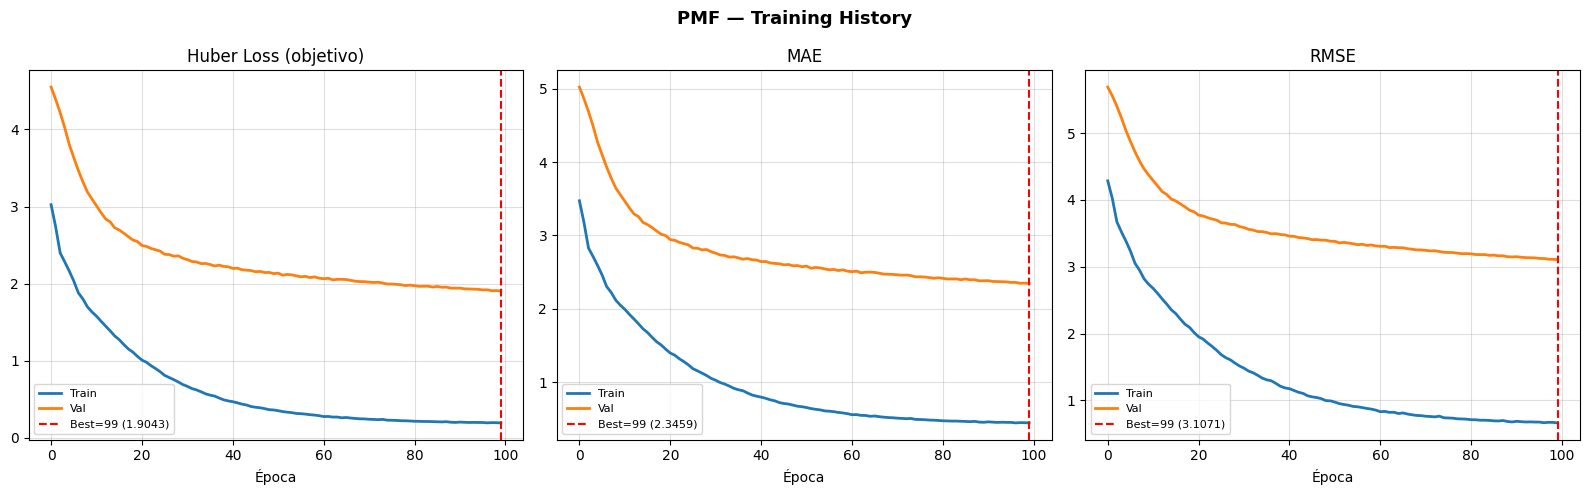

In [8]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)
user_means, item_means, global_mean = compute_stats(sparse_matrix)

pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.01,
    lambda_V   = 0.01,
    lr         = 0.1,   # Adam es mucho más estable con lr fijo
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam'   # <-- cambio clave
)

pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

In [14]:
pmf = PMF(
    n_factors   = 20,
    lambda_U    = 0.1,    # era 0.01 → subir x10
    lambda_V    = 0.1,
    lr          = 0.1,  # bajar lr
    n_epochs    = 100,
    batch_size  = 2048,
    optimizer   = 'adam',
    huber_delta = 1.0,
    log_every   = 1,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

 Epoch   Train Huber   Train MAE   Train RMSE   Val Huber   Val MAE   Val RMSE        Status
-----------------------------------------------------------------------------------------------
     1        3.6679      4.1357       4.8925      4.5862    5.0651     5.6920        ✔ best
     2        2.6219      3.0680       3.8528      4.0664    4.5395     5.2584        ✔ best
     3        2.2159      2.6490       3.4343      3.6758    4.1440     4.9007        ✔ best
     4        2.0614      2.4904       3.2505      3.3805    3.8453     4.6267        ✔ best
     5        1.9357      2.3642       3.0970      3.1537    3.6169     4.4005        ✔ best
     6        1.7959      2.2213       2.9293      2.9274    3.3868     4.1805        ✔ best
     7        1.6480      2.0706       2.7435      2.7491    3.2063     3.9971        ✔ best
     8        1.5458      1.9649       2.6149      2.5935    3.0471     3.8475        ✔ best
     9        1.4431      1.8592       2.4883      2.4911    2.9457

KeyboardInterrupt: 

In [ ]:
pmf = PMF(
    n_factors   = 20,
    lambda_U    = 0.5,    # era 0.1 → subir x5
    lambda_V    = 0.5,
    lr          = 0.1,  # bajar lr
    n_epochs    = 100,
    batch_size  = 2048,
    optimizer   = 'adam',
    huber_delta = 1.0,
    log_every   = 1,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

 Epoch   Train Huber   Train MAE   Train RMSE   Val Huber   Val MAE   Val RMSE        Status
-----------------------------------------------------------------------------------------------
     1        5.6929      6.1895       6.5224      6.0954    6.5936     6.8446        ✔ best
     2        4.1379      4.6214       5.2467      4.6927    5.1826     5.7028        ✔ best
     3        2.7260      3.1885       3.8844      3.5632    4.0403     4.7008        ✔ best
     4        2.1416      2.5918       3.2399      3.1520    3.6256     4.2995        ✔ best
     5        1.9716      2.4130       3.0662      2.9226    3.3928     4.0719        ✔ best
     6        1.9537      2.3963       3.0337      2.8306    3.2997     3.9628        ✔ best
     7        1.8835      2.3283       2.9294      2.7245    3.1934     3.8426        ✔ best
     8        1.7556      2.1986       2.7656      2.5714    3.0381     3.6820        ✔ best
     9        1.6343      2.0769       2.5993      2.4181    2.8824

KeyboardInterrupt: 

## User and Item biases

In [29]:
'''
Lo que captura cada componente del modelo:
r̂_ui = μ  +  b_u[u]  +  b_i[i]  +  U[u] · V[i]
        ↑       ↑           ↑            ↑
    media    "este      "este ítem    interacción
    global   usuario    recibe        latente
             puntúa     puntuaciones  usuario-ítem
             alto"       altas"
'''

'\nLo que captura cada componente del modelo:\nr̂_ui = μ  +  b_u[u]  +  b_i[i]  +  U[u] · V[i]\n        ↑       ↑           ↑            ↑\n    media    "este      "este ítem    interacción\n    global   usuario    recibe        latente\n             puntúa     puntuaciones  usuario-ítem\n             alto"       altas"\n'

In [19]:
class PMF:
    def __init__(self, n_factors=20, lambda_U=0.5, lambda_V=0.5,
                 lambda_bu=0.01, lambda_bi=0.01,
                 lr=0.001, n_epochs=100, batch_size=1024,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='adam', huber_delta=1.0, log_every=1,
                 use_biases=True):
        self.n_factors   = n_factors
        self.lambda_U    = lambda_U
        self.lambda_V    = lambda_V
        self.lambda_bu   = lambda_bu   # regularización bias usuario
        self.lambda_bi   = lambda_bi   # regularización bias ítem
        self.lr          = lr
        self.n_epochs    = n_epochs
        self.batch_size  = batch_size
        self.clip_min    = clip_min
        self.clip_max    = clip_max
        self.random_state = random_state
        self.optimizer   = optimizer
        self.huber_delta = huber_delta
        self.log_every   = log_every
        self.use_biases  = use_biases  # False → PMF puro sin biases

        self.U   = self.V   = None
        self.b_u = self.b_i = None     # (n_users,)  (n_items,)
        self.mu  = None                # media global (escalar)
        self.history = []

    # ── Inicialización ────────────────────────────────────────────────────────
    def _init_factors(self, n_users, n_items, global_mean):
        rng   = np.random.default_rng(self.random_state)
        scale = 1 / np.sqrt(self.n_factors)
        self.U   = rng.normal(0, scale, (n_users, self.n_factors))
        self.V   = rng.normal(0, scale, (n_items, self.n_factors))
        self.mu  = global_mean
        self.b_u = np.zeros(n_users)
        self.b_i = np.zeros(n_items)

        if self.optimizer == 'adam':
            self.mU  = np.zeros_like(self.U);   self.vU  = np.zeros_like(self.U)
            self.mV  = np.zeros_like(self.V);   self.vV  = np.zeros_like(self.V)
            self.mbu = np.zeros_like(self.b_u); self.vbu = np.zeros_like(self.b_u)
            self.mbi = np.zeros_like(self.b_i); self.vbi = np.zeros_like(self.b_i)
            self._adam_t = 0

    # ── Predicción ────────────────────────────────────────────────────────────
    def _predict_batch(self, u_idx, i_idx):
        """
        r̂_ui = μ + b_u[u] + b_i[i] + U[u] · V[i]
        Sin biases:
        r̂_ui = μ + U[u] · V[i]
        """
        dot = np.sum(self.U[u_idx] * self.V[i_idx], axis=1)
        if self.use_biases:
            return self.mu + self.b_u[u_idx] + self.b_i[i_idx] + dot
        return self.mu + dot

    # ── Huber ─────────────────────────────────────────────────────────────────
    def _huber_grad(self, errors):
        d = self.huber_delta
        return np.where(np.abs(errors) <= d, errors, d * np.sign(errors))

    # ── Métricas ──────────────────────────────────────────────────────────────
    def _metrics(self, u_idx, i_idx, ratings):
        preds  = np.clip(self._predict_batch(u_idx, i_idx), self.clip_min, self.clip_max)
        errors = ratings - preds
        huber  = np.where(
            np.abs(errors) <= self.huber_delta,
            0.5 * errors ** 2,
            self.huber_delta * (np.abs(errors) - 0.5 * self.huber_delta)
        ).mean()
        return {
            'huber': huber,
            'mae'  : np.mean(np.abs(errors)),
            'rmse' : np.sqrt(np.mean(errors ** 2))
        }

    # ── Adam update ───────────────────────────────────────────────────────────
    def _adam_update(self, param, m, v, grad, beta1=0.9, beta2=0.999, eps=1e-8):
        self._adam_t += 1
        m[:] = beta1 * m + (1 - beta1) * grad
        v[:] = beta2 * v + (1 - beta2) * grad ** 2
        param -= self.lr * (m / (1 - beta1**self._adam_t)) / \
                           (np.sqrt(v / (1 - beta2**self._adam_t)) + eps)

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    def fit(self, x_train, y_train, x_val, y_val,
            user_map, item_map, patience=10):

        train_users = x_train['user'].map(user_map).values
        train_items = x_train['item'].map(item_map).values
        train_r     = y_train.values.astype(np.float64)

        val_mask    = x_val['user'].isin(user_map) & x_val['item'].isin(item_map)
        val_users   = x_val.loc[val_mask, 'user'].map(user_map).values
        val_items   = x_val.loc[val_mask, 'item'].map(item_map).values
        val_r       = y_val[val_mask].values.astype(np.float64)

        # Media global para inicializar μ
        global_mean = float(train_r.mean())
        self._init_factors(len(user_map), len(item_map), global_mean)

        n_samples  = len(train_r)
        rng        = np.random.default_rng(self.random_state)
        best_val   = np.inf
        best_state = self._save_state()
        no_improve = 0

        print(f"{'Epoch':>6}  {'Tr Huber':>9}  {'Tr MAE':>8}  {'Tr RMSE':>9}  "
              f"{'Va Huber':>9}  {'Va MAE':>8}  {'Va RMSE':>9}  {'Status':>12}")
        print("─" * 85)

        for epoch in range(self.n_epochs):
            perm   = rng.permutation(n_samples)
            u_shuf = train_users[perm]
            i_shuf = train_items[perm]
            r_shuf = train_r[perm]

            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                u_b = u_shuf[start:end]
                i_b = i_shuf[start:end]
                r_b = r_shuf[start:end]

                U_b    = self.U[u_b]
                V_b    = self.V[i_b]
                dot    = np.sum(U_b * V_b, axis=1)

                if self.use_biases:
                    preds  = self.mu + self.b_u[u_b] + self.b_i[i_b] + dot
                else:
                    preds  = self.mu + dot

                errors = r_b - preds
                dgrad  = self._huber_grad(errors)   # dL/d(error)

                # ── Gradientes ────────────────────────────────────────────────
                # dL/dU = -dgrad * V + λ_U * U
                grad_U  = -dgrad[:, None] * V_b  + self.lambda_U  * U_b
                grad_V  = -dgrad[:, None] * U_b  + self.lambda_V  * V_b

                if self.use_biases:
                    grad_bu = -dgrad + self.lambda_bu * self.b_u[u_b]
                    grad_bi = -dgrad + self.lambda_bi * self.b_i[i_b]

                # ── Updates ───────────────────────────────────────────────────
                if self.optimizer == 'adam':
                    for idx in np.unique(u_b):
                        mask = u_b == idx
                        self._adam_update(self.U[idx],   self.mU[idx],  self.vU[idx],
                                          grad_U[mask].mean(axis=0))
                        if self.use_biases:
                            self._adam_update(self.b_u[idx:idx+1], self.mbu[idx:idx+1],
                                              self.vbu[idx:idx+1],
                                              np.array([grad_bu[mask].mean()]))
                    for idx in np.unique(i_b):
                        mask = i_b == idx
                        self._adam_update(self.V[idx],   self.mV[idx],  self.vV[idx],
                                          grad_V[mask].mean(axis=0))
                        if self.use_biases:
                            self._adam_update(self.b_i[idx:idx+1], self.mbi[idx:idx+1],
                                              self.vbi[idx:idx+1],
                                              np.array([grad_bi[mask].mean()]))
                else:
                    for idx in np.unique(u_b):
                        mask = u_b == idx
                        self.U[idx]   -= self.lr * grad_U[mask].mean(axis=0)
                        if self.use_biases:
                            self.b_u[idx] -= self.lr * grad_bu[mask].mean()
                    for idx in np.unique(i_b):
                        mask = i_b == idx
                        self.V[idx]   -= self.lr * grad_V[mask].mean(axis=0)
                        if self.use_biases:
                            self.b_i[idx] -= self.lr * grad_bi[mask].mean()

            # ── Métricas por época ────────────────────────────────────────────
            tr = self._metrics(train_users, train_items, train_r)
            vl = self._metrics(val_users,   val_items,   val_r)

            if vl['mae'] < best_val:
                best_val   = vl['mae']
                best_state = self._save_state()
                no_improve = 0
                status     = '✔ best'
            else:
                no_improve += 1
                status = f'no imp {no_improve}/{patience}'

            self.history.append({'epoch': epoch + 1,
                                  **{f'train_{k}': v for k, v in tr.items()},
                                  **{f'val_{k}':   v for k, v in vl.items()}})

            if (epoch + 1) % self.log_every == 0:
                print(f"{epoch+1:>6}  {tr['huber']:>9.4f}  {tr['mae']:>8.4f}  {tr['rmse']:>9.4f}  "
                      f"{vl['huber']:>9.4f}  {vl['mae']:>8.4f}  {vl['rmse']:>9.4f}  {status:>12}")

            if no_improve >= patience:
                print(f"\nEarly stopping época {epoch+1} | best val MAE: {best_val:.4f}")
                break

        self._load_state(best_state)
        return self

    # ── Guardar / restaurar pesos ─────────────────────────────────────────────
    def _save_state(self):
        state = {'U': self.U.copy(), 'V': self.V.copy()}
        if self.use_biases:
            state.update({'b_u': self.b_u.copy(), 'b_i': self.b_i.copy()})
        return state

    def _load_state(self, state):
        self.U, self.V = state['U'], state['V']
        if self.use_biases:
            self.b_u, self.b_i = state['b_u'], state['b_i']

    # ── Plot ──────────────────────────────────────────────────────────────────
    def plot_loss(self):
        df = pd.DataFrame(self.history).set_index('epoch')
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        for ax, m, title in zip(axes, ['huber','mae','rmse'],
                                       ['Huber Loss','MAE','RMSE']):
            ax.plot(df[f'train_{m}'], label='Train', linewidth=2)
            ax.plot(df[f'val_{m}'],   label='Val',   linewidth=2)
            best_ep = int(df[f'val_{m}'].idxmin())
            ax.axvline(best_ep, color='red', linestyle='--',
                       label=f'Best={best_ep} ({df[f"val_{m}"].min():.4f})')
            ax.set_title(title); ax.set_xlabel('Época')
            ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
        bias_str = 'con biases' if self.use_biases else 'sin biases'
        fig.suptitle(f'PMF ({bias_str}) — Training History', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    # ── Predicción test ───────────────────────────────────────────────────────
    def predict_test(self, x_test, user_map, item_map,
                     user_means, item_means, global_mean,
                     cold_start_unknown_user='global_mean',
                     cold_start_unknown_item='user_mean',
                     cold_start_both='const_7'):

        def _cold(strat, user_idx=None, item_idx=None):
            if strat == 'item_mean':
                v = item_means[item_idx] if item_idx is not None else np.nan
            elif strat == 'user_mean':
                v = user_means[user_idx] if user_idx is not None else np.nan
            elif strat == 'global_mean':
                v = global_mean
            elif strat.startswith('const_'):
                v = float(strat.split('_')[1])
            else:
                v = np.nan
            return global_mean if np.isnan(v) else v

        ids, preds = [], []
        for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc='Predicting'):
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            ids.append(row_id)

            u_known = user_id in user_map
            i_known = item_id in item_map

            if not u_known and not i_known:
                preds.append(_cold(cold_start_both))
            elif not u_known:
                preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            elif not i_known:
                preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            else:
                u = user_map[user_id]
                i = item_map[item_id]
                p = float(self.mu + self.b_u[u] + self.b_i[i] + np.dot(self.U[u], self.V[i]))
                if not self.use_biases:
                    p = float(self.mu + np.dot(self.U[u], self.V[i]))
                preds.append(np.clip(p, self.clip_min, self.clip_max))

        return pd.DataFrame({'id': ids, 'rating': preds})

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9822    1.4085     1.7699     0.9743    1.4020     1.7540        ✔ best
     2     0.9376    1.3586     1.7228     0.9457    1.3706     1.7240        ✔ best
     3     0.9049    1.3219     1.6887     0.9260    1.3493     1.7040        ✔ best
     4     0.8785    1.2920     1.6616     0.9109    1.3329     1.6892        ✔ best
     5     0.8564    1.2666     1.6392     0.8988    1.3196     1.6777        ✔ best
     6     0.8375    1.2448     1.6199     0.8887    1.3084     1.6683        ✔ best
     7     0.8210    1.2255     1.6030     0.8803    1.2990     1.6606        ✔ best
     8     0.8064    1.2082     1.5878     0.8732    1.2909     1.6541        ✔ best
     9     0.7933    1.1927     1.5741     0.8670    1.2839     1.6485        ✔ best
    10     0.7814    1.1784     1.5616     0.8617    1.2777     

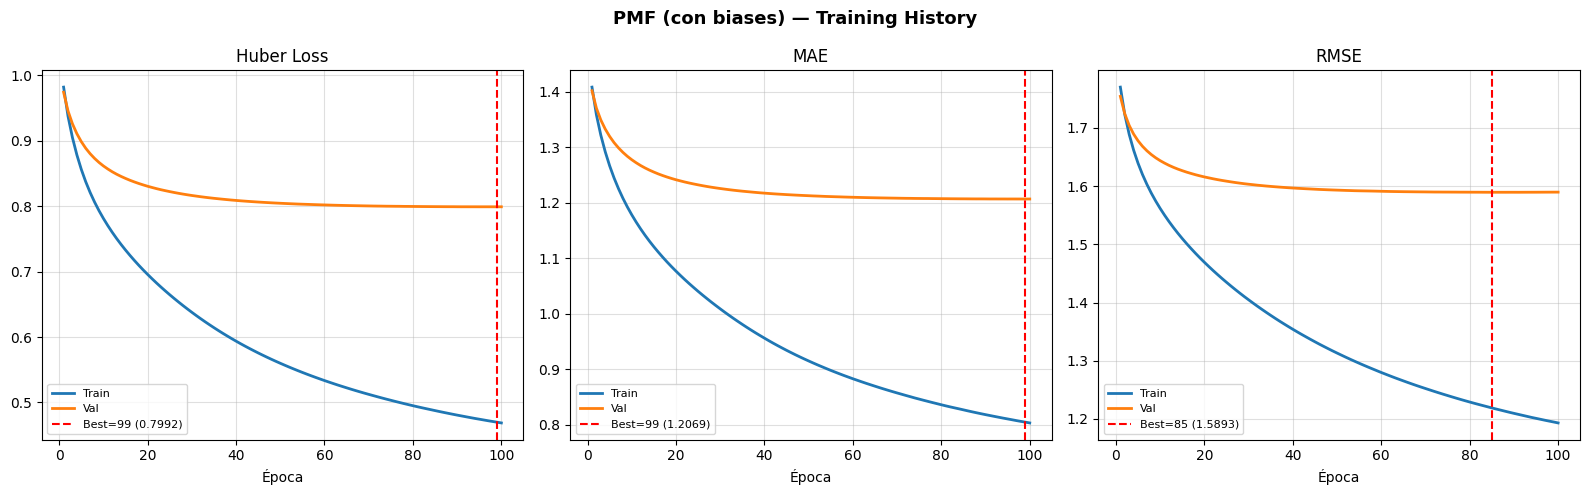

In [22]:
# Con biases (recomendado)
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.5,
    lambda_V   = 0.5,
    lambda_bu  = 0.05,   # biases necesitan menos regularización que factores
    lambda_bi  = 0.05,
    lr         = 0.001,
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam',
    use_biases = True,   # ← activar biases
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()

In [33]:
# Con biases (recomendado)
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.75,
    lambda_V   = 0.75,
    lambda_bu  = 0.075,   # biases necesitan menos regularización que factores
    lambda_bi  = 0.075,
    lr         = 0.0025,
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam',
    use_biases = True,   # ← activar biases
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=3
)

pmf.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9127    1.3317     1.7016     0.9194    1.3426     1.6998        ✔ best
     2     0.8516    1.2619     1.6413     0.8796    1.2983     1.6627        ✔ best
     3     0.8139    1.2173     1.6026     0.8578    1.2734     1.6428        ✔ best
     4     0.7859    1.1840     1.5733     0.8438    1.2572     1.6297        ✔ best
     5     0.7635    1.1575     1.5492     0.8339    1.2460     1.6206        ✔ best
     6     0.7443    1.1349     1.5284     0.8265    1.2376     1.6134        ✔ best
     7     0.7277    1.1152     1.5102     0.8210    1.2313     1.6082        ✔ best
     8     0.7128    1.0976     1.4938     0.8165    1.2265     1.6041        ✔ best
     9     0.6994    1.0818     1.4788     0.8129    1.2224     1.6007        ✔ best
    10     0.6871    1.0672     1.4650     0.8101    1.2194     

KeyboardInterrupt: 

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9134    1.3326     1.7021     0.9200    1.3433     1.7003        ✔ best
     2     0.8528    1.2635     1.6420     0.8806    1.2996     1.6633        ✔ best
     3     0.8153    1.2194     1.6033     0.8590    1.2750     1.6434        ✔ best
     4     0.7875    1.1865     1.5741     0.8451    1.2591     1.6302        ✔ best
     5     0.7652    1.1602     1.5501     0.8353    1.2481     1.6211        ✔ best
     6     0.7461    1.1377     1.5293     0.8280    1.2398     1.6139        ✔ best
     7     0.7296    1.1182     1.5111     0.8225    1.2336     1.6086        ✔ best
     8     0.7148    1.1007     1.4947     0.8180    1.2288     1.6045        ✔ best
     9     0.7014    1.0849     1.4797     0.8144    1.2248     1.6011        ✔ best
    10     0.6892    1.0704     1.4660     0.8116    1.2218     

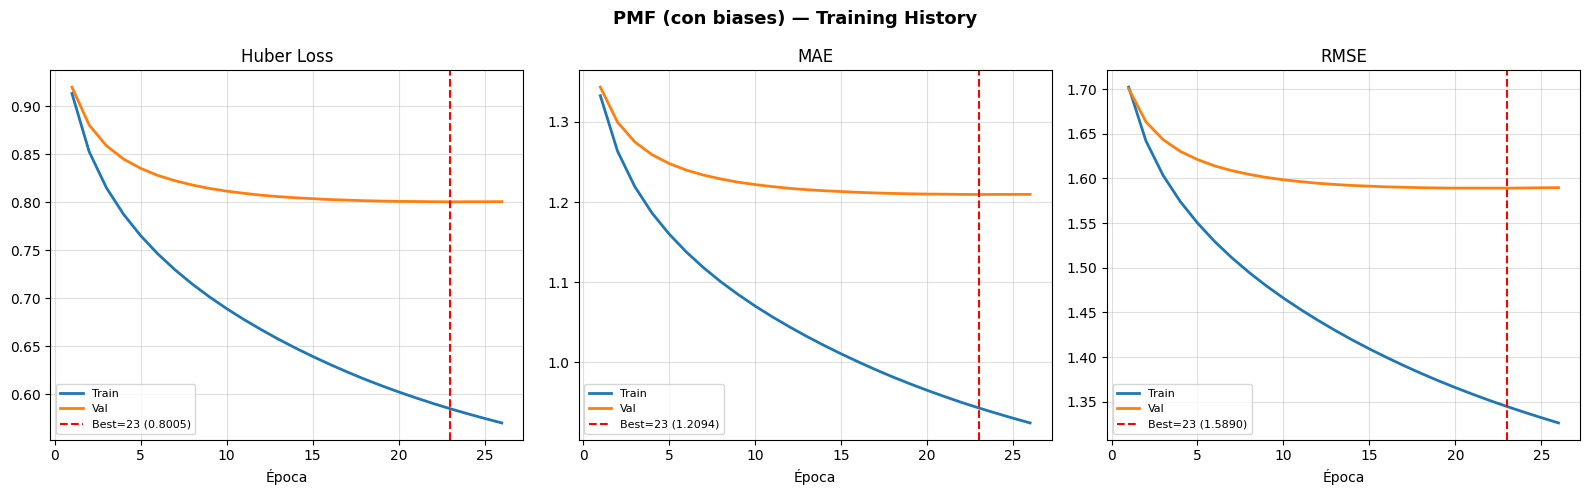

In [35]:
# Con biases (recomendado)
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.75,
    lambda_V   = 0.75,
    lambda_bu  = 0.1,   # biases necesitan menos regularización que factores
    lambda_bi  = 0.1,
    lr         = 0.0025,
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam',
    use_biases = True,   # ← activar biases
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=3
)

pmf.plot_loss()

## SGD

In [ ]:
# Configuración recomendada para SGD
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 1,   # puedes bajar lambda porque SGD ya regulariza implícitamente
    lambda_V   = 1,
    lambda_bu  = 0.1,
    lambda_bi  = 0.1,
    lr         = 0.005,   # lr más alto que con Adam (SGD no adapta el lr)
    n_epochs   = 200,    # más épocas porque converge más lento
    batch_size = 256,    # ← bajar de 2048 a 256 es clave con SGD
    optimizer  = 'sgd',
    use_biases = True,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=3
)

pmf.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9735    1.4000     1.7674     0.9638    1.3909     1.7461        ✔ best
     2     0.9322    1.3537     1.7277     0.9297    1.3537     1.7134        ✔ best
     3     0.9050    1.3230     1.7010     0.9083    1.3299     1.6935        ✔ best
     4     0.8842    1.2996     1.6801     0.8931    1.3130     1.6789        ✔ best
     5     0.8673    1.2806     1.6633     0.8814    1.2998     1.6681        ✔ best
     6     0.8529    1.2640     1.6486     0.8720    1.2892     1.6593        ✔ best
     7     0.8405    1.2502     1.6357     0.8642    1.2806     1.6521        ✔ best
     8     0.8293    1.2374     1.6242     0.8577    1.2730     1.6460        ✔ best
     9     0.8192    1.2261     1.6136     0.8519    1.2666     1.6405        ✔ best
    10     0.8099    1.2155     1.6039     0.8470    1.2609     

KeyboardInterrupt: 

## Number of factors

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9719    1.3994     1.7651     0.9624    1.3903     1.7443        ✔ best
     2     0.9310    1.3532     1.7260     0.9287    1.3530     1.7121        ✔ best
     3     0.9040    1.3226     1.6996     0.9075    1.3292     1.6924        ✔ best
     4     0.8834    1.2993     1.6789     0.8924    1.3123     1.6780        ✔ best
     5     0.8667    1.2803     1.6622     0.8808    1.2993     1.6673        ✔ best
     6     0.8523    1.2638     1.6476     0.8715    1.2887     1.6586        ✔ best
     7     0.8400    1.2500     1.6349     0.8638    1.2803     1.6514        ✔ best
     8     0.8288    1.2372     1.6234     0.8573    1.2728     1.6454        ✔ best
     9     0.8188    1.2259     1.6129     0.8516    1.2666     1.6400        ✔ best
    10     0.8096    1.2153     1.6033     0.8467    1.2609     

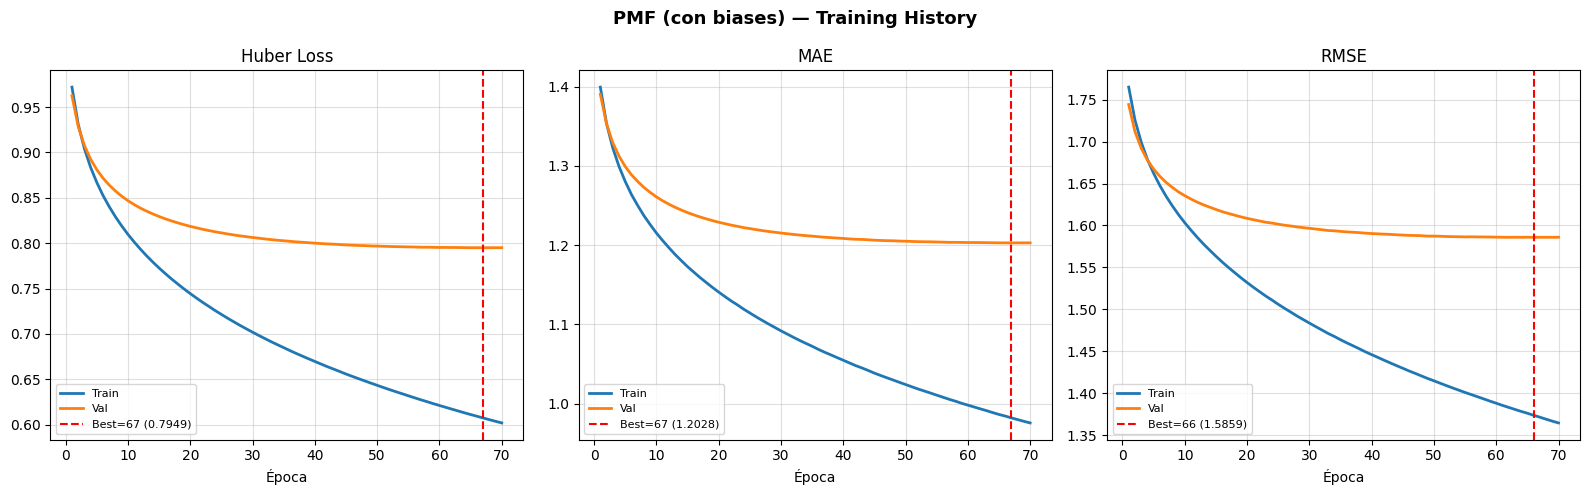

In [37]:
pmf = PMF(
    n_factors  = 30,
    lambda_U   = 1,   # puedes bajar lambda porque SGD ya regulariza implícitamente
    lambda_V   = 1,
    lambda_bu  = 0.1,
    lambda_bi  = 0.1,
    lr         = 0.005,   # lr más alto que con Adam (SGD no adapta el lr)
    n_epochs   = 200,    # más épocas porque converge más lento
    batch_size = 256,    # ← bajar de 2048 a 256 es clave con SGD
    optimizer  = 'sgd',
    use_biases = True,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=3
)

pmf.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9797    1.4043     1.7754     0.9704    1.3957     1.7544        ✔ best
     2     0.9369    1.3570     1.7339     0.9347    1.3570     1.7196        ✔ best
     3     0.9087    1.3257     1.7061     0.9124    1.3323     1.6986        ✔ best
     4     0.8874    1.3019     1.6845     0.8966    1.3150     1.6833        ✔ best
     5     0.8701    1.2826     1.6671     0.8845    1.3017     1.6720        ✔ best
     6     0.8554    1.2659     1.6520     0.8747    1.2909     1.6628        ✔ best
     7     0.8427    1.2519     1.6388     0.8668    1.2822     1.6553        ✔ best
     8     0.8313    1.2389     1.6270     0.8600    1.2745     1.6490        ✔ best
     9     0.8211    1.2275     1.6162     0.8541    1.2681     1.6433        ✔ best
    10     0.8116    1.2168     1.6063     0.8490    1.2623     

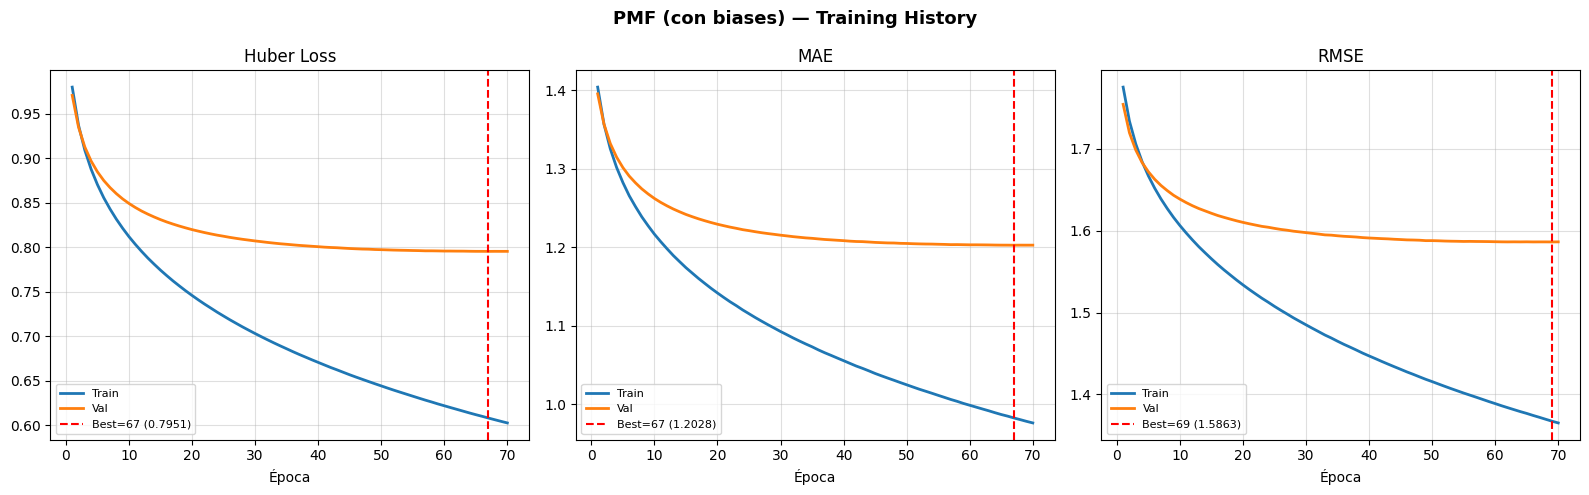

In [38]:
pmf = PMF(
    n_factors  = 10,
    lambda_U   = 1,   # puedes bajar lambda porque SGD ya regulariza implícitamente
    lambda_V   = 1,
    lambda_bu  = 0.1,
    lambda_bi  = 0.1,
    lr         = 0.005,   # lr más alto que con Adam (SGD no adapta el lr)
    n_epochs   = 200,    # más épocas porque converge más lento
    batch_size = 256,    # ← bajar de 2048 a 256 es clave con SGD
    optimizer  = 'sgd',
    use_biases = True,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=3
)

pmf.plot_loss()

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9756    1.4011     1.7701     0.9684    1.3946     1.7518        ✔ best
     2     0.9338    1.3545     1.7299     0.9331    1.3563     1.7178        ✔ best
     3     0.9062    1.3237     1.7028     0.9110    1.3319     1.6971        ✔ best
     4     0.8853    1.3002     1.6817     0.8954    1.3146     1.6819        ✔ best
     5     0.8683    1.2812     1.6647     0.8834    1.3013     1.6707        ✔ best
     6     0.8538    1.2646     1.6499     0.8737    1.2906     1.6616        ✔ best
     7     0.8413    1.2507     1.6369     0.8659    1.2820     1.6542        ✔ best
     8     0.8301    1.2379     1.6253     0.8591    1.2743     1.6479        ✔ best
     9     0.8199    1.2266     1.6146     0.8533    1.2679     1.6423        ✔ best
    10     0.8106    1.2160     1.6049     0.8483    1.2622     

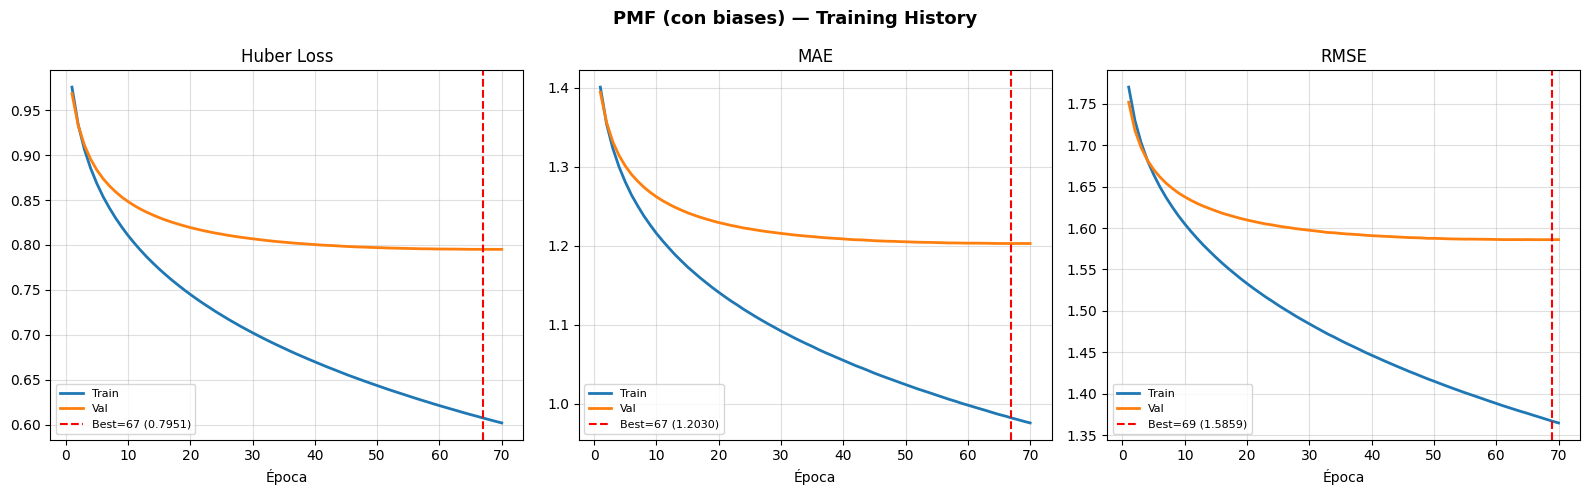

In [39]:
pmf = PMF(
    n_factors  = 15,
    lambda_U   = 1,   # puedes bajar lambda porque SGD ya regulariza implícitamente
    lambda_V   = 1,
    lambda_bu  = 0.1,
    lambda_bi  = 0.1,
    lr         = 0.005,   # lr más alto que con Adam (SGD no adapta el lr)
    n_epochs   = 200,    # más épocas porque converge más lento
    batch_size = 256,    # ← bajar de 2048 a 256 es clave con SGD
    optimizer  = 'sgd',
    use_biases = True,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=3
)

pmf.plot_loss()

## Predict PMF

In [ ]:
def predict_pmf_val(pmf, x_val, user_map, item_map,
                    user_means, item_means, global_mean,
                    clip_min=1.0, clip_max=10.0):
    """
    Predicciones PMF en validación con cold-start:
        usuario desconocido, ítem conocido   → global_mean
        usuario conocido,   ítem desconocido → user_mean
        ambos desconocidos                   → const_7
        ambos conocidos                      → μ + b_u + b_i + U·V
    """
    preds = []

    for _, row in tqdm(x_val.iterrows(), total=len(x_val), desc='Predicting PMF val'):
        user_id = row.iloc[0]
        item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            preds.append(7.0)

        elif not u_known:
            # usuario desconocido → media global del ítem
            item_idx = item_map[item_id]
            v = item_means[item_idx]
            preds.append(float(global_mean if np.isnan(v) else v))

        elif not i_known:
            # ítem desconocido → media del usuario
            user_idx = user_map[user_id]
            v = user_means[user_idx]
            preds.append(float(global_mean if np.isnan(v) else v))

        else:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            preds.append(np.clip(p, clip_min, clip_max))

    return np.array(preds)


def predict_pmf_test(pmf, x_test, user_map, item_map,
                     user_means, item_means, global_mean,
                     clip_min=1.0, clip_max=10.0):
    """
    Igual que predict_pmf_val pero recibe columna id y devuelve DataFrame.
    """
    ids, preds = [], []

    for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc='Predicting PMF test'):
        row_id  = row.iloc[0]
        user_id = row.iloc[1]
        item_id = row.iloc[2]

        u_known = user_id in user_map
        i_known = item_id in item_map

        ids.append(row_id)

        if not u_known and not i_known:
            preds.append(7.0)

        elif not u_known:
            item_idx = item_map[item_id]
            v = item_means[item_idx]
            preds.append(float(global_mean if np.isnan(v) else v))

        elif not i_known:
            user_idx = user_map[user_id]
            v = user_means[user_idx]
            preds.append(float(global_mean if np.isnan(v) else v))

        else:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            preds.append(np.clip(p, clip_min, clip_max))

    return pd.DataFrame({'ID': ids, 'rating': preds})

In [54]:
# Test → DataFrame para submission
submission = predict_pmf_test(
    pmf, df_test, user_map, item_map,
    user_means, item_means, global_mean
)
submission.to_csv('submission_pmf.csv', index=False)

Predicting PMF test: 100%|██████████| 43320/43320 [00:01<00:00, 32602.28it/s]


## Ensemble

 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     1     0.9735    1.4000     1.7674     0.9638    1.3909     1.7461        ✔ best
     2     0.9322    1.3537     1.7277     0.9297    1.3537     1.7134        ✔ best
     3     0.9050    1.3230     1.7010     0.9083    1.3299     1.6935        ✔ best
     4     0.8842    1.2996     1.6801     0.8931    1.3130     1.6789        ✔ best
     5     0.8673    1.2806     1.6633     0.8814    1.2998     1.6681        ✔ best
     6     0.8529    1.2640     1.6486     0.8720    1.2892     1.6593        ✔ best
     7     0.8405    1.2502     1.6357     0.8642    1.2806     1.6521        ✔ best
     8     0.8293    1.2374     1.6242     0.8577    1.2730     1.6460        ✔ best
     9     0.8192    1.2261     1.6136     0.8519    1.2666     1.6405        ✔ best
    10     0.8099    1.2155     1.6039     0.8470    1.2609     

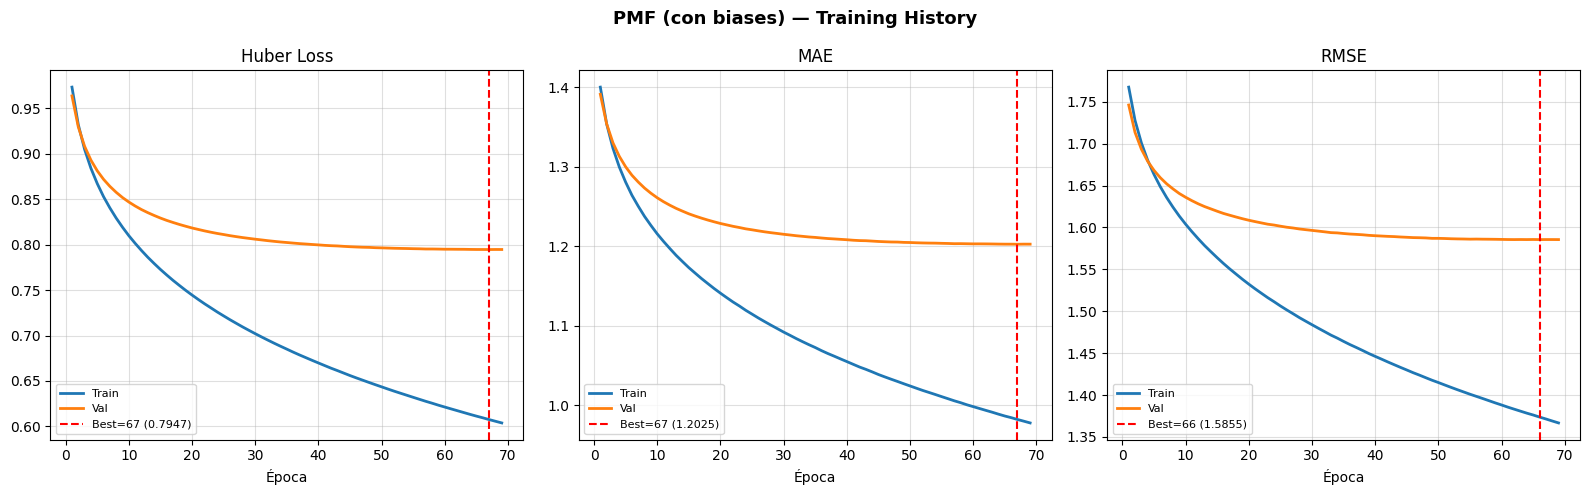

In [40]:
# Configuración recomendada para SGD
pmf = PMF(
    n_factors  = 20,
    lambda_U   = 1,   # puedes bajar lambda porque SGD ya regulariza implícitamente
    lambda_V   = 1,
    lambda_bu  = 0.1,
    lambda_bi  = 0.1,
    lr         = 0.005,   # lr más alto que con Adam (SGD no adapta el lr)
    n_epochs   = 200,    # más épocas porque converge más lento
    batch_size = 256,    # ← bajar de 2048 a 256 es clave con SGD
    optimizer  = 'sgd',
    use_biases = True,
)
pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=2
)

pmf.plot_loss()

In [46]:
from ipynb.fs.defs.competition1 import get_user_distances_for_item, predict

In [43]:
def predict_val(x_val, sparse_matrix, user_map, item_map,
                user_means, item_means, global_mean,
                metric='jaccard_weighted', k=5,
                cold_start_unknown_user='global_mean',
                cold_start_unknown_item='user_mean',
                cold_start_both='const_7'):

    def _cold_pred(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    preds = []

    for _, row in tqdm(x_val.iterrows(), total=len(x_val), desc="Predicting val"):
        user_id = row.iloc[0]
        item_id = row.iloc[1]

        user_known = user_id in user_map
        item_known = item_id in item_map

        if not user_known and not item_known:
            preds.append(_cold_pred(cold_start_both))
            continue

        if not user_known:
            preds.append(_cold_pred(cold_start_unknown_user, item_idx=item_map[item_id]))
            continue

        if not item_known:
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_map[user_id]))
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        if len(distances) == 0:
            preds.append(_cold_pred(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        k_actual   = min(k, len(sorted_idx))
        top_idx    = sorted_idx[:k_actual]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        preds.append(np.dot(weights, top_r) / weights.sum())

    return np.array(preds)

In [44]:
val_preds_knn = predict_val(
    x_val, sparse_matrix, user_map, item_map,
    user_means, item_means, global_mean,
    metric = 'jaccard_weighted',
    k      = 4,
)

val_preds_pmf = []
for _, row in x_val.iterrows():
    user_id, item_id = row.iloc[0], row.iloc[1]
    if user_id in user_map and item_id in item_map:
        u = user_map[user_id]
        i = item_map[item_id]
        p = float(pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i]))
        val_preds_pmf.append(np.clip(p, 1, 10))
    else:
        val_preds_pmf.append(global_mean)
val_preds_pmf = np.array(val_preds_pmf)

# ── Comprobación ──────────────────────────────────────────────────────────────
errors_pmf = y_val.values - val_preds_pmf
errors_knn = y_val.values - val_preds_knn

corr     = np.corrcoef(errors_pmf, errors_knn)[0, 1]
pmf_wins = np.mean(np.abs(errors_pmf) < np.abs(errors_knn))
knn_wins = np.mean(np.abs(errors_knn) < np.abs(errors_pmf))

print(f"Correlación de errores : {corr:.4f}")
print(f"PMF gana en            : {pmf_wins*100:.1f}% de los casos")
print(f"KNN gana en            : {knn_wins*100:.1f}% de los casos")

Predicting val: 100%|██████████| 39036/39036 [02:06<00:00, 308.89it/s]


Correlación de errores : 0.8024
PMF gana en            : 46.6% de los casos
KNN gana en            : 45.0% de los casos


In [47]:
def ensemble_predict_val(val_preds_pmf, val_preds_knn, y_val, clip_min=1.0, clip_max=10.0):
    """Busca el mejor alpha en validación y muestra la gráfica."""

    alphas  = np.arange(0, 1.05, 0.05)
    results = []

    for alpha in alphas:
        blended = alpha * val_preds_pmf + (1 - alpha) * val_preds_knn
        blended = np.clip(blended, clip_min, clip_max)
        mae     = np.mean(np.abs(blended - y_val.values))
        rmse    = np.sqrt(np.mean((blended - y_val.values) ** 2))
        results.append({'alpha': alpha, 'mae': mae, 'rmse': rmse})

    df_res   = pd.DataFrame(results)
    best_row = df_res.loc[df_res['mae'].idxmin()]
    best_alpha = best_row['alpha']

    print(f"{'Alpha':>7}  {'MAE':>8}  {'RMSE':>8}")
    print("─" * 28)
    for _, r in df_res.iterrows():
        marker = '  ✔ best' if r['alpha'] == best_alpha else ''
        print(f"{r['alpha']:>7.2f}  {r['mae']:>8.4f}  {r['rmse']:>8.4f}{marker}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, title in [(ax1, 'mae', 'MAE'), (ax2, 'rmse', 'RMSE')]:
        ax.plot(df_res['alpha'], df_res[metric], marker='o', linewidth=2)
        ax.axvline(best_alpha, color='red', linestyle='--',
                   label=f'Best α={best_alpha:.2f} ({best_row[metric]:.4f})')
        # Líneas baseline
        mae_pmf  = np.mean(np.abs(val_preds_pmf - y_val.values))
        mae_knn  = np.mean(np.abs(val_preds_knn - y_val.values))
        ax.axhline(mae_pmf if metric == 'mae' else np.sqrt(np.mean((val_preds_pmf - y_val.values)**2)),
                   color='steelblue', linestyle=':', linewidth=1.5, label='PMF solo')
        ax.axhline(mae_knn if metric == 'mae' else np.sqrt(np.mean((val_preds_knn - y_val.values)**2)),
                   color='darkorange', linestyle=':', linewidth=1.5, label='KNN solo')
        ax.set_xlabel('Alpha  (0=KNN puro, 1=PMF puro)')
        ax.set_ylabel(title)
        ax.set_title(f'Ensemble — {title}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)

    fig.suptitle('PMF + KNN Ensemble', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return float(best_alpha)


def ensemble_predict_test(pmf, x_test, sparse_matrix, user_map, item_map,
                          user_means, item_means, global_mean,
                          best_alpha, k,
                          metric            = 'jaccard_weighted',
                          cold_start_unknown_user = 'global_mean',
                          cold_start_unknown_item = 'user_mean',
                          cold_start_both         = 'const_7',
                          clip_min=1.0, clip_max=10.0):

    # PMF predictions
    test_pmf = pmf.predict_test(
        x_test, user_map, item_map,
        user_means, item_means, global_mean,
        cold_start_unknown_user = cold_start_unknown_user,
        cold_start_unknown_item = cold_start_unknown_item,
        cold_start_both         = cold_start_both,
    ).set_index('id')['rating']

    # KNN predictions
    test_knn = predict(
        x_test, sparse_matrix, user_map, item_map,
        user_means, item_means, global_mean,
        metric  = metric,
        k       = k,
        cold_start_unknown_user = cold_start_unknown_user,
        cold_start_unknown_item = cold_start_unknown_item,
        cold_start_both         = cold_start_both,
    ).set_index('id')['rating']

    blended = best_alpha * test_pmf + (1 - best_alpha) * test_knn
    blended = np.clip(blended, clip_min, clip_max)

    return pd.DataFrame({'id': blended.index, 'rating': blended.values})

  Alpha       MAE      RMSE
────────────────────────────
   0.00    1.3928    1.8427
   0.05    1.3831    1.8201
   0.10    1.3736    1.7991
   0.15    1.3644    1.7796
   0.20    1.3557    1.7616
   0.25    1.3474    1.7453
   0.30    1.3398    1.7307
   0.35    1.3329    1.7178
   0.40    1.3267    1.7067
   0.45    1.3215    1.6973
   0.50    1.3173    1.6898
   0.55    1.3140    1.6841
   0.60    1.3118    1.6803
   0.65    1.3107    1.6783  ✔ best
   0.70    1.3109    1.6783
   0.75    1.3124    1.6801
   0.80    1.3151    1.6838
   0.85    1.3191    1.6894
   0.90    1.3242    1.6968
   0.95    1.3304    1.7061
   1.00    1.3376    1.7172


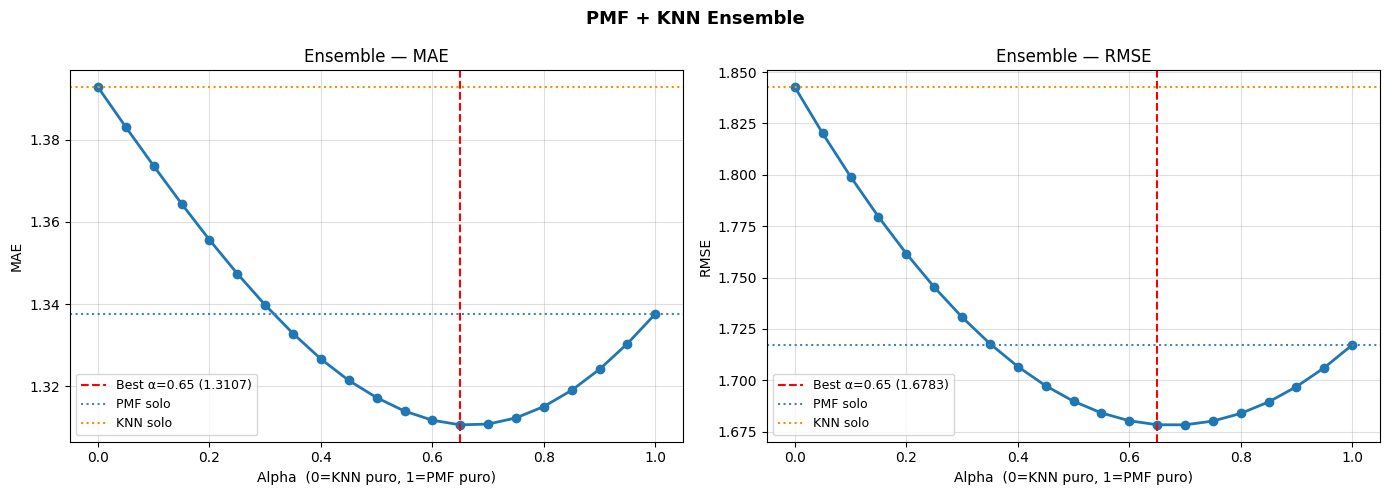

In [48]:
# 1. Encontrar mejor alpha
best_alpha = ensemble_predict_val(val_preds_pmf, val_preds_knn, y_val)

In [49]:
# Construir x_val con columna id para que funcione predict_test
x_val_with_id = x_val.copy().reset_index()  
# → columnas: [index, user, item]

val_preds_pmf_df = pmf.predict_test(
    x_val_with_id,
    user_map, item_map,
    user_means, item_means, global_mean,
    cold_start_unknown_user = 'global_mean',
    cold_start_unknown_item = 'user_mean',
    cold_start_both         = 'const_7'
)
val_preds_pmf = val_preds_pmf_df['rating'].values

# Verificar que ahora coincide con el entrenamiento
mae_check = np.mean(np.abs(val_preds_pmf - y_val.values))
print(f"MAE PMF val (debería ser ≈1.20): {mae_check:.4f}")

Predicting: 100%|██████████| 39036/39036 [00:01<00:00, 29240.84it/s]

MAE PMF val (debería ser ≈1.20): 1.2476


In [50]:
known_mask = x_val['user'].isin(user_map) & x_val['item'].isin(item_map)
print(f"Pares conocidos   : {known_mask.sum()} ({known_mask.mean()*100:.1f}%)")
print(f"Pares cold-start  : {(~known_mask).sum()} ({(~known_mask).mean()*100:.1f}%)")

# MAE solo sobre conocidos
mae_known = np.mean(np.abs(val_preds_pmf[known_mask] - y_val.values[known_mask]))
mae_cold  = np.mean(np.abs(val_preds_pmf[~known_mask] - y_val.values[~known_mask]))
print(f"MAE conocidos     : {mae_known:.4f}")   # → debería ser ≈1.20
print(f"MAE cold-start    : {mae_cold:.4f}")    # → este lastra el resultado

Pares conocidos   : 23243 (59.5%)
Pares cold-start  : 15793 (40.5%)
MAE conocidos     : 1.2025
MAE cold-start    : 1.3140


In [51]:
file_test = "data/test.csv"
df_test = pd.read_csv(file_test, header=0)
full_sparse_matrix, full_user_map, full_item_map = create_sparse_matrix(df[["user", "item"]], df["rating"])
# Precomputar stats una sola vez (si no lo tienes ya)
full_user_means, full_item_means, full_global_mean = compute_stats(sparse_matrix)

In [52]:
# 2. Predicciones finales
submission = ensemble_predict_test(
    pmf, df_test, sparse_matrix, user_map, item_map,
    user_means, item_means, global_mean,
    best_alpha = best_alpha,
    k          = 4,
)

submission.to_csv('submission_ensemble.csv', index=False)

Predicting: 100%|██████████| 43320/43320 [01:36<00:00, 448.48it/s] 


## Other

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FASE 1 — Sin datos nuevos
# ① Reentrenar con train+val completo para test
# ② Biases aprendidos como cold-start
# ③ Ensemble PMF + KNN sobre conocidos
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# ── PASO 0: Utilidades compartidas ────────────────────────────────────────────

def evaluate_predictions(preds, y_true, label=''):
    mae  = np.mean(np.abs(preds - y_true))
    rmse = np.sqrt(np.mean((preds - y_true) ** 2))
    print(f"{label:<30} MAE={mae:.4f}  RMSE={rmse:.4f}")
    return mae, rmse


def evaluate_disaggregated(preds, y_true, known_mask, label='Model'):
    """Evalúa separando casos conocidos de cold-start."""
    print(f"\n── {label} ──────────────────────────────────────────")
    mae_total, rmse_total = evaluate_predictions(preds, y_true,
                                                  f"  Total      ({len(y_true):>5})")
    mae_k, _ = evaluate_predictions(preds[known_mask],  y_true[known_mask],
                                     f"  Conocidos  ({known_mask.sum():>5})")
    mae_c, _ = evaluate_predictions(preds[~known_mask], y_true[~known_mask],
                                     f"  Cold-start ({(~known_mask).sum():>5})")
    return {'total': mae_total, 'known': mae_k, 'cold': mae_c}


# ── PASO 1: Reentrenar con train+val ─────────────────────────────────────────

def retrain_full(x_train, y_train, x_val, y_val, pmf_params,
                 n_epochs_full=None, patience_val=10):
    """
    ① Determina épocas óptimas entrenando con train/val
    ② Reentrena con train+val usando esas épocas fijas

    pmf_params : dict con los hiperparámetros de PMF (sin n_epochs)
    """

    # ── 1A: encontrar n_epochs óptimo con train/val ───────────────────────────
    print("═" * 60)
    print("STEP 1A — Encontrando épocas óptimas con train/val...")
    print("═" * 60)

    sparse_tv, user_map_tv, item_map_tv = create_sparse_matrix(x_train, y_train)
    user_means_tv, item_means_tv, global_mean_tv = compute_stats(sparse_tv)

    pmf_val = PMF(**pmf_params)
    pmf_val.fit(x_train, y_train, x_val, y_val,
                user_map_tv, item_map_tv, patience=patience_val)

    best_epoch = int(pd.DataFrame(pmf_val.history)['val_mae'].idxmin()) + 1
    print(f"\n→ Épocas óptimas encontradas: {best_epoch}")

    if n_epochs_full is not None:
        best_epoch = n_epochs_full
        print(f"→ Sobreescrito por n_epochs_full={n_epochs_full}")

    # ── 1B: reentrenar con train+val ─────────────────────────────────────────
    print("\n" + "═" * 60)
    print(f"STEP 1B — Reentrenando con train+val ({best_epoch} épocas)...")
    print("═" * 60)

    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    user_means_full, item_means_full, global_mean_full = compute_stats(sparse_full)

    full_params = {**pmf_params, 'n_epochs': best_epoch}
    pmf_full = PMF(**full_params)

    # val = train para que no rompa el código, patience=999 para no parar
    pmf_full.fit(x_full, y_full, x_full, y_full,
                 user_map_full, item_map_full, patience=999)

    print(f"\n✔ Modelo reentrenado con {len(x_full)} muestras")
    print(f"  Usuarios en train+val : {len(user_map_full)}")
    print(f"  Ítems en train+val    : {len(item_map_full)}")

    return (pmf_full, sparse_full, user_map_full, item_map_full,
            user_means_full, item_means_full, global_mean_full,
            pmf_val, sparse_tv, user_map_tv, item_map_tv,
            user_means_tv, item_means_tv, global_mean_tv)


# ── PASO 2: Predicción PMF con biases como cold-start ────────────────────────

def predict_pmf_with_bias_coldstart(pmf, x, user_map, item_map,
                                     clip_min=1.0, clip_max=10.0,
                                     has_id_col=False):
    """
    ② Usa biases aprendidos para cold-start en lugar de constantes:
        usuario conocido,  ítem desconocido → μ + b_u[u]
        usuario desconocido, ítem conocido  → μ + b_i[i]
        ambos desconocidos                  → μ
        ambos conocidos                     → μ + b_u + b_i + U·V
    """
    ids, preds = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Predicting PMF'):
        if has_id_col:
            row_id  = row.iloc[0]
            user_id = row.iloc[1]
            item_id = row.iloc[2]
            ids.append(row_id)
        else:
            user_id = row.iloc[0]
            item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if u_known and i_known:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])

        elif u_known and not i_known:
            # ② bias usuario como cold-start para ítem desconocido
            u = user_map[user_id]
            p = pmf.mu + pmf.b_u[u]

        elif not u_known and i_known:
            # ② bias ítem como cold-start para usuario desconocido
            i = item_map[item_id]
            p = pmf.mu + pmf.b_i[i]

        else:
            # ambos desconocidos → solo media global
            p = pmf.mu

        preds.append(np.clip(p, clip_min, clip_max))

    if has_id_col:
        return pd.DataFrame({'id': ids, 'rating': preds})
    return np.array(preds)


# ── PASO 3: Predicción KNN ────────────────────────────────────────────────────

def predict_knn_array(x_val, sparse_matrix, user_map, item_map,
                      user_means, item_means, global_mean,
                      metric='jaccard_weighted', k=5,
                      cold_start_unknown_user='global_mean',
                      cold_start_unknown_item='user_mean',
                      cold_start_both='const_7',
                      clip_min=1.0, clip_max=10.0):
    """Predicción KNN devolviendo np.array (para ensemble en val)."""

    def _cold(strat, user_idx=None, item_idx=None):
        if strat == 'item_mean':
            v = item_means[item_idx] if item_idx is not None else np.nan
        elif strat == 'user_mean':
            v = user_means[user_idx] if user_idx is not None else np.nan
        elif strat == 'global_mean':
            v = global_mean
        elif strat.startswith('const_'):
            v = float(strat.split('_')[1])
        else:
            v = np.nan
        return global_mean if (isinstance(v, float) and np.isnan(v)) else v

    preds = []
    for _, row in tqdm(x_val.iterrows(), total=len(x_val), desc='Predicting KNN'):
        user_id = row.iloc[0]
        item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            preds.append(_cold(cold_start_both))
            continue
        if not u_known:
            preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            continue
        if not i_known:
            preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, [metric], user_means
        )
        distances = distances[metric]

        if len(distances) == 0:
            preds.append(_cold(cold_start_unknown_item, user_idx=user_idx))
            continue

        sorted_idx = np.argsort(distances)
        top_idx    = sorted_idx[:min(k, len(sorted_idx))]
        top_d      = distances[top_idx]
        top_r      = ratings[top_idx]
        weights    = 1 / (top_d + 1e-8)
        preds.append(np.clip(np.dot(weights, top_r) / weights.sum(), clip_min, clip_max))

    return np.array(preds)


# ── PASO 4: Ensemble ──────────────────────────────────────────────────────────

def find_best_alpha(val_preds_pmf, val_preds_knn, y_val,
                    known_mask=None, clip_min=1.0, clip_max=10.0):
    """
    ③ Busca el mejor alpha sobre los casos conocidos (donde KNN y PMF aportan).
    Si known_mask=None evalúa sobre todos.
    """
    mask  = known_mask if known_mask is not None else np.ones(len(y_val), dtype=bool)
    p_pmf = val_preds_pmf[mask]
    p_knn = val_preds_knn[mask]
    y     = y_val[mask]

    alphas, results = np.arange(0, 1.05, 0.05), []
    for alpha in alphas:
        blended = np.clip(alpha * p_pmf + (1 - alpha) * p_knn, clip_min, clip_max)
        mae     = np.mean(np.abs(blended - y))
        rmse    = np.sqrt(np.mean((blended - y) ** 2))
        results.append({'alpha': alpha, 'mae': mae, 'rmse': rmse})

    df      = pd.DataFrame(results)
    best    = df.loc[df['mae'].idxmin()]
    best_alpha = float(best['alpha'])

    print(f"\n{'Alpha':>7}  {'MAE':>8}  {'RMSE':>8}")
    print("─" * 30)
    for _, r in df.iterrows():
        marker = '  ✔ best' if r['alpha'] == best_alpha else ''
        print(f"{r['alpha']:>7.2f}  {r['mae']:>8.4f}  {r['rmse']:>8.4f}{marker}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in [(ax1, 'mae', 'MAE'), (ax2, 'rmse', 'RMSE')]:
        ax.plot(df['alpha'], df[metric], marker='o', linewidth=2)
        ax.axvline(best_alpha, color='red', linestyle='--',
                   label=f'Best α={best_alpha:.2f} ({best[metric]:.4f})')
        ax.axhline(np.mean(np.abs(p_pmf - y)) if metric == 'mae'
                   else np.sqrt(np.mean((p_pmf - y)**2)),
                   color='steelblue', linestyle=':', label='PMF solo')
        ax.axhline(np.mean(np.abs(p_knn - y)) if metric == 'mae'
                   else np.sqrt(np.mean((p_knn - y)**2)),
                   color='darkorange', linestyle=':', label='KNN solo')
        ax.set_xlabel('Alpha  (0=KNN, 1=PMF)')
        ax.set_ylabel(title)
        ax.set_title(f'Ensemble — {title}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)
    suffix = f'sobre conocidos ({mask.sum()})' if known_mask is not None else 'total'
    fig.suptitle(f'PMF + KNN Ensemble ({suffix})', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    return best_alpha


def ensemble_test(pmf_full, x_test,
                  sparse_tv, user_map_tv, item_map_tv,
                  user_means_tv, item_means_tv, global_mean_tv,
                  user_map_full, item_map_full,
                  best_alpha, k, metric='jaccard_weighted',
                  clip_min=1.0, clip_max=10.0):
    """Genera predicciones finales de test con el ensemble."""

    print("Generando predicciones PMF (train+val)...")
    x_test_noid = x_test.iloc[:, 1:]   # quitar columna id
    preds_pmf   = predict_pmf_with_bias_coldstart(
        pmf_full, x_test_noid, user_map_full, item_map_full,
        clip_min=clip_min, clip_max=clip_max, has_id_col=False
    )

    print("Generando predicciones KNN (train only)...")
    preds_knn = predict_knn_array(
        x_test_noid, sparse_tv, user_map_tv, item_map_tv,
        user_means_tv, item_means_tv, global_mean_tv,
        metric=metric, k=k, clip_min=clip_min, clip_max=clip_max
    )

    blended = np.clip(best_alpha * preds_pmf + (1 - best_alpha) * preds_knn,
                      clip_min, clip_max)

    submission = pd.DataFrame({'id': x_test.iloc[:, 0].values, 'rating': blended})
    return submission

## Other 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
from collections import Counter


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 1 — Análisis cold-start sobre train+val
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_coldstart(x_train, y_train, x_val, y_val, user_map, item_map):
    """
    Para cada caso de cold-start evalúa todas las estrategias posibles
    sobre los datos de validación y genera gráficas.

    Casos:
        unknown_user : usuario no está en train, ítem sí
        unknown_item : ítem no está en train, usuario sí
        both_unknown : ninguno está en train
    """

    # ── Estadísticas globales calculadas sobre train ──────────────────────────
    all_ratings    = y_train.values
    global_mean    = float(np.mean(all_ratings))
    global_median  = float(np.median(all_ratings))
    global_mode    = float(stats.mode(all_ratings, keepdims=True).mode[0])

    # Media/mediana/moda por usuario en train
    train_df = x_train.copy()
    train_df.columns = ['user', 'item']
    train_df['rating'] = y_train.values

    user_stats = train_df.groupby('user')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: stats.mode(x, keepdims=True).mode[0]
    )
    item_stats = train_df.groupby('item')['rating'].agg(
        mean='mean', median='median',
        mode=lambda x: stats.mode(x, keepdims=True).mode[0]
    )

    # ── Clasificar casos en val ───────────────────────────────────────────────
    val_df = x_val.copy()
    val_df.columns = ['user', 'item']
    val_df['rating'] = y_val.values
    val_df['u_known'] = val_df['user'].isin(user_map)
    val_df['i_known'] = val_df['item'].isin(item_map)

    cases = {
        'unknown_user' : val_df[ val_df['u_known'] & ~val_df['i_known']],  # usuario conocido, ítem no  -- wait, unknown_user means user not in train
        'unknown_item' : val_df[~val_df['u_known'] &  val_df['i_known']],  # ítem conocido, usuario no
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }
    # Fix: unknown_user = user NOT in train
    cases = {
        'unknown_user' : val_df[~val_df['u_known'] &  val_df['i_known']],
        'unknown_item' : val_df[ val_df['u_known'] & ~val_df['i_known']],
        'both_unknown' : val_df[~val_df['u_known'] & ~val_df['i_known']],
    }

    print(f"Casos cold-start en validación:")
    for case, df in cases.items():
        print(f"  {case:<15}: {len(df):>5} ({len(df)/len(val_df)*100:.1f}%)")

    best_strategies = {}

    for case, df in cases.items():
        if len(df) == 0:
            print(f"\n[{case}] Sin casos en validación, skipping.")
            continue

        y_true = df['rating'].values

        # ── Construir estrategias disponibles para este caso ──────────────────
        strategies = {}

        # Constantes 1-10
        for v in range(1, 11):
            strategies[f'const_{v}'] = np.full(len(df), float(v))

        # Globales
        strategies['global_mean']   = np.full(len(df), global_mean)
        strategies['global_median'] = np.full(len(df), global_median)
        strategies['global_mode']   = np.full(len(df), global_mode)

        # Basadas en ítem (cuando el ítem es conocido)
        if case == 'unknown_user':
            item_mean_preds, item_med_preds, item_mode_preds = [], [], []
            for item_id in df['item']:
                if item_id in item_stats.index:
                    item_mean_preds.append(item_stats.loc[item_id, 'mean'])
                    item_med_preds.append(item_stats.loc[item_id, 'median'])
                    item_mode_preds.append(item_stats.loc[item_id, 'mode'])
                else:
                    item_mean_preds.append(global_mean)
                    item_med_preds.append(global_median)
                    item_mode_preds.append(global_mode)
            strategies['item_mean']   = np.array(item_mean_preds)
            strategies['item_median'] = np.array(item_med_preds)
            strategies['item_mode']   = np.array(item_mode_preds)

        # Basadas en usuario (cuando el usuario es conocido)
        if case == 'unknown_item':
            user_mean_preds, user_med_preds, user_mode_preds = [], [], []
            for user_id in df['user']:
                if user_id in user_stats.index:
                    user_mean_preds.append(user_stats.loc[user_id, 'mean'])
                    user_med_preds.append(user_stats.loc[user_id, 'median'])
                    user_mode_preds.append(user_stats.loc[user_id, 'mode'])
                else:
                    user_mean_preds.append(global_mean)
                    user_med_preds.append(global_median)
                    user_mode_preds.append(global_mode)
            strategies['user_mean']   = np.array(user_mean_preds)
            strategies['user_median'] = np.array(user_med_preds)
            strategies['user_mode']   = np.array(user_mode_preds)

        # ── Calcular MAE para cada estrategia ─────────────────────────────────
        results = {}
        for name, preds in strategies.items():
            results[name] = float(np.mean(np.abs(preds - y_true)))

        results_df = pd.DataFrame({'strategy': list(results.keys()),
                                   'mae': list(results.values())})
        results_df = results_df.sort_values('mae').reset_index(drop=True)
        best_strat = results_df.iloc[0]['strategy']
        best_strategies[case] = {
            'strategy' : best_strat,
            'mae'      : results_df.iloc[0]['mae'],
            'all'      : results_df
        }

        print(f"\n── {case} (n={len(df)}) ──────────────────────────────")
        print(results_df.to_string(index=False))
        print(f"  → Mejor estrategia: {best_strat} (MAE={results_df.iloc[0]['mae']:.4f})")

        # ── Plot ──────────────────────────────────────────────────────────────
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        # Barras MAE por estrategia
        colors = ['#70ad47' if s == best_strat else
                  '#5b9bd5' if s.startswith('const_') else
                  '#ed7d31' if 'mean' in s or 'median' in s or 'mode' in s else
                  '#a9a9a9'
                  for s in results_df['strategy']]

        bars = ax1.bar(range(len(results_df)), results_df['mae'],
                       color=colors, edgecolor='white')
        ax1.set_xticks(range(len(results_df)))
        ax1.set_xticklabels(results_df['strategy'], rotation=45, ha='right', fontsize=8)
        ax1.set_ylabel('MAE')
        ax1.set_title(f'[{case}] MAE por estrategia')
        ax1.grid(True, axis='y', alpha=0.4)

        y_off = (results_df['mae'].max() - results_df['mae'].min()) * 0.01 + 0.001
        for bar, val in zip(bars, results_df['mae']):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_off,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=7)

        from matplotlib.patches import Patch
        ax1.legend(handles=[
            Patch(color='#70ad47', label='Best'),
            Patch(color='#5b9bd5', label='Constant (1-10)'),
            Patch(color='#ed7d31', label='Stat-based'),
        ], fontsize=8)

        # Distribución de ratings reales en este caso
        ax2.hist(y_true, bins=np.arange(0.5, 11.5, 1), color='steelblue',
                 edgecolor='white', alpha=0.8)
        ax2.axvline(global_mean,   color='red',    linestyle='--', label=f'global mean={global_mean:.2f}')
        ax2.axvline(global_median, color='orange', linestyle='--', label=f'global median={global_median:.2f}')
        ax2.set_xlabel('Rating')
        ax2.set_ylabel('Count')
        ax2.set_title(f'[{case}] Distribución de ratings reales')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.4)

        fig.suptitle(f'Cold-start analysis — {case}', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return best_strategies, user_stats, item_stats, global_mean


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 2+3 — Entrenamiento ensemble de PMF con diferentes semillas
# ═══════════════════════════════════════════════════════════════════════════════

def _cold_pred_from_strategy(strategy_name, user_id, item_id,
                              user_stats, item_stats, global_mean):
    """Aplica la estrategia de cold-start a una muestra concreta."""
    if strategy_name.startswith('const_'):
        return float(strategy_name.split('_')[1])
    if strategy_name == 'global_mean':
        return global_mean
    if strategy_name == 'item_mean':
        return item_stats.loc[item_id, 'mean'] if item_id in item_stats.index else global_mean
    if strategy_name == 'item_median':
        return item_stats.loc[item_id, 'median'] if item_id in item_stats.index else global_mean
    if strategy_name == 'item_mode':
        return item_stats.loc[item_id, 'mode'] if item_id in item_stats.index else global_mean
    if strategy_name == 'user_mean':
        return user_stats.loc[user_id, 'mean'] if user_id in user_stats.index else global_mean
    if strategy_name == 'user_median':
        return user_stats.loc[user_id, 'median'] if user_id in user_stats.index else global_mean
    if strategy_name == 'user_mode':
        return user_stats.loc[user_id, 'mode'] if user_id in user_stats.index else global_mean
    return global_mean


def predict_pmf_real_mae(pmf, x_val, y_val, user_map, item_map,
                         best_strategies, user_stats, item_stats, global_mean,
                         clip_min=1.0, clip_max=10.0):
    """
    Predicción en val usando las mejores estrategias de cold-start.
    Devuelve (preds_array, real_mae).
    """
    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    preds = []
    for _, row in x_val.iterrows():
        user_id = row.iloc[0]
        item_id = row.iloc[1]
        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            p = _cold_pred_from_strategy(cs_both, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        elif not u_known:
            p = _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        elif not i_known:
            p = _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                          user_stats, item_stats, global_mean)
        else:
            u = user_map[user_id]
            i = item_map[item_id]
            p = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            p = float(np.clip(p, clip_min, clip_max))

        preds.append(p)

    preds    = np.array(preds)
    real_mae = float(np.mean(np.abs(preds - y_val.values)))
    return preds, real_mae


def train_pmf_ensemble(x_train, y_train, x_val, y_val,
                       user_map, item_map,
                       best_strategies, user_stats, item_stats, global_mean,
                       pmf_params, n_models=5, seeds=None,
                       clip_min=1.0, clip_max=10.0):
    """
    Entrena n_models PMF con semillas distintas.
    Para cada modelo guarda:
        - época de parada
        - MAE real en validación (con cold-start óptimo)
        - predicciones en validación
        - el propio modelo
    """
    if seeds is None:
        seeds = list(range(n_models))

    ensemble_info = []

    for idx, seed in enumerate(seeds):
        print(f"\n{'═'*60}")
        print(f"  Modelo {idx+1}/{n_models}  —  seed={seed}")
        print(f"{'═'*60}")

        params = {**pmf_params, 'random_state': seed}
        pmf    = PMF(**params)
        pmf.fit(x_train, y_train, x_val, y_val,
                user_map, item_map,
                patience=3)

        stop_epoch = len(pmf.history)
        val_preds, real_mae = predict_pmf_real_mae(
            pmf, x_val, y_val, user_map, item_map,
            best_strategies, user_stats, item_stats, global_mean,
            clip_min, clip_max
        )

        print(f"\n  → Stop epoch : {stop_epoch}")
        print(f"  → MAE real   : {real_mae:.4f}")

        ensemble_info.append({
            'seed'       : seed,
            'model'      : pmf,
            'stop_epoch' : stop_epoch,
            'real_mae'   : real_mae,
            'val_preds'  : val_preds,
        })

    return ensemble_info


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 4 — Predicción ponderada por inverso de MAE
# ═══════════════════════════════════════════════════════════════════════════════

def weighted_predict(models_info, x, user_map, item_map,
                     best_strategies, user_stats, item_stats, global_mean,
                     clip_min=1.0, clip_max=10.0, has_id_col=False):
    """
    Predicción ensemble ponderada por 1/MAE.
    Más peso a los modelos con menor MAE de validación.
    """

    maes    = np.array([m['real_mae'] for m in models_info])
    weights = 1 / maes
    weights = weights / weights.sum()   # normalizar a suma=1

    print(f"\nPesos del ensemble:")
    for info, w in zip(models_info, weights):
        print(f"  seed={info['seed']}  MAE={info['real_mae']:.4f}  peso={w:.4f}")

    cs_unknown_user = best_strategies['unknown_user']['strategy']
    cs_unknown_item = best_strategies['unknown_item']['strategy']
    cs_both         = best_strategies['both_unknown']['strategy']

    ids_out, preds_out = [], []

    for _, row in tqdm(x.iterrows(), total=len(x), desc='Weighted predict'):
        if has_id_col:
            row_id  = row.iloc[0]
            user_id = row.iloc[1]
            item_id = row.iloc[2]
            ids_out.append(row_id)
        else:
            user_id = row.iloc[0]
            item_id = row.iloc[1]

        u_known = user_id in user_map
        i_known = item_id in item_map

        if not u_known and not i_known:
            p = _cold_pred_from_strategy(cs_both, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        if not u_known:
            p = _cold_pred_from_strategy(cs_unknown_user, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        if not i_known:
            p = _cold_pred_from_strategy(cs_unknown_item, user_id, item_id,
                                          user_stats, item_stats, global_mean)
            preds_out.append(p)
            continue

        # ── Pares conocidos: media ponderada de todos los modelos ─────────────
        model_preds = []
        for info in models_info:
            pmf = info['model']
            u   = user_map[user_id]
            i   = item_map[item_id]
            p   = pmf.mu + pmf.b_u[u] + pmf.b_i[i] + np.dot(pmf.U[u], pmf.V[i])
            model_preds.append(np.clip(p, clip_min, clip_max))

        p_final = float(np.dot(weights, model_preds))
        preds_out.append(np.clip(p_final, clip_min, clip_max))

    if has_id_col:
        return pd.DataFrame({'ID': ids_out, 'rating': preds_out})
    return np.array(preds_out)


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 5 — Reentrenar sobre train+val con media de épocas de parada
# ═══════════════════════════════════════════════════════════════════════════════

def train_full_ensemble(x_train, y_train, x_val, y_val,
                        ensemble_info, pmf_params,
                        best_strategies, user_stats, item_stats,
                        n_models=5, seeds=None,
                        clip_min=1.0, clip_max=10.0):
    """
    ⑤ Reentrena el ensemble sobre train+val usando la media de épocas de parada.
    """
    mean_epochs = int(np.round(np.mean([m['stop_epoch'] for m in ensemble_info])))
    print(f"\nÉpocas de parada por modelo: {[m['stop_epoch'] for m in ensemble_info]}")
    print(f"Media de épocas → {mean_epochs}")

    x_full = pd.concat([x_train, x_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

    sparse_full, user_map_full, item_map_full = create_sparse_matrix(x_full, y_full)
    user_means_full, item_means_full, global_mean_full = compute_stats(sparse_full)

    if seeds is None:
        seeds = [m['seed'] for m in ensemble_info]

    full_params = {**pmf_params, 'n_epochs': mean_epochs}
    full_ensemble_info = []

    for idx, seed in enumerate(seeds):
        print(f"\n{'═'*60}")
        print(f"  Modelo FULL {idx+1}/{n_models}  —  seed={seed}  epochs={mean_epochs}")
        print(f"{'═'*60}")

        params = {**full_params, 'random_state': seed}
        pmf    = PMF(**params)

        # val = train (sin early stopping real, épocas fijas)
        pmf.fit(x_full, y_full, x_full, y_full,
                user_map_full, item_map_full, patience=999)

        full_ensemble_info.append({
            'seed'  : seed,
            'model' : pmf,
            # MAE del modelo equivalente en val para mantener los pesos
            'real_mae' : ensemble_info[idx]['real_mae'],
        })

    return full_ensemble_info, user_map_full, item_map_full, global_mean_full


# ═══════════════════════════════════════════════════════════════════════════════
# PASO 6 — Resumen y plot del ensemble
# ═══════════════════════════════════════════════════════════════════════════════

def plot_ensemble_summary(ensemble_info):
    seeds       = [m['seed']       for m in ensemble_info]
    maes        = [m['real_mae']   for m in ensemble_info]
    stop_epochs = [m['stop_epoch'] for m in ensemble_info]
    weights     = 1 / np.array(maes); weights /= weights.sum()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # MAE por modelo
    colors = ['#70ad47' if m == min(maes) else '#5b9bd5' for m in maes]
    axes[0].bar([f'seed={s}' for s in seeds], maes, color=colors, edgecolor='white')
    axes[0].set_title('MAE real por modelo')
    axes[0].set_ylabel('MAE')
    axes[0].grid(True, axis='y', alpha=0.4)
    for i, v in enumerate(maes):
        axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    # Pesos
    axes[1].bar([f'seed={s}' for s in seeds], weights, color='#ed7d31', edgecolor='white')
    axes[1].set_title('Pesos ensemble (1/MAE normalizado)')
    axes[1].set_ylabel('Peso')
    axes[1].grid(True, axis='y', alpha=0.4)
    for i, v in enumerate(weights):
        axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    # Épocas de parada
    axes[2].bar([f'seed={s}' for s in seeds], stop_epochs, color='#9b59b6', edgecolor='white')
    axes[2].axhline(np.mean(stop_epochs), color='red', linestyle='--',
                    label=f'Media={np.mean(stop_epochs):.1f}')
    axes[2].set_title('Época de parada por modelo')
    axes[2].set_ylabel('Época')
    axes[2].legend(); axes[2].grid(True, axis='y', alpha=0.4)

    fig.suptitle('PMF Ensemble — Resumen', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

Casos cold-start en validación:
  unknown_user   :  3264 (8.4%)
  unknown_item   : 11212 (28.7%)
  both_unknown   :  1317 (3.4%)

── unknown_user (n=3264) ──────────────────────────────
     strategy      mae
      const_8 1.369792
global_median 1.369792
  global_mode 1.369792
  global_mean 1.428172
  item_median 1.458333
    item_mean 1.459555
      const_7 1.517463
    item_mode 1.649510
      const_9 1.754596
      const_6 2.043199
     const_10 2.439645
      const_5 2.750306
      const_4 3.648591
      const_3 4.594056
      const_2 5.570772
      const_1 6.560355
  → Mejor estrategia: const_8 (MAE=1.3698)


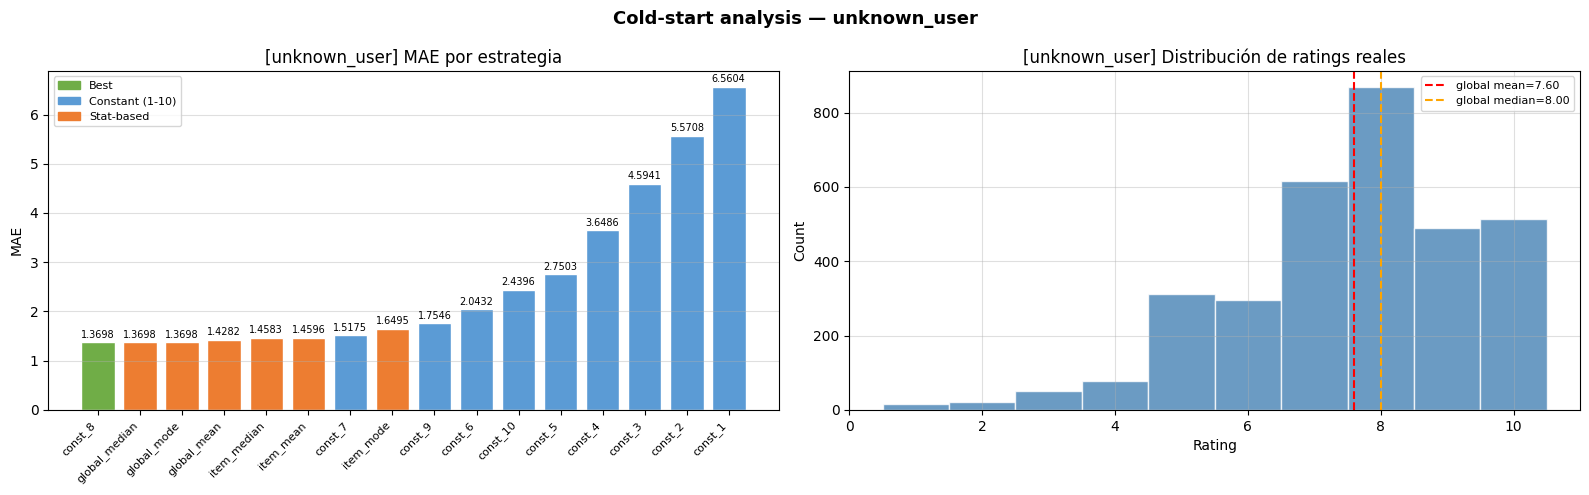


── unknown_item (n=11212) ──────────────────────────────
     strategy      mae
  user_median 1.209329
    user_mean 1.248337
    user_mode 1.323403
      const_8 1.530503
global_median 1.530503
  global_mode 1.530503
  global_mean 1.560968
      const_7 1.607563
      const_9 1.890474
      const_6 2.037103
     const_10 2.528541
      const_5 2.648056
      const_4 3.553157
      const_3 4.502854
      const_2 5.480557
      const_1 6.471459
  → Mejor estrategia: user_median (MAE=1.2093)


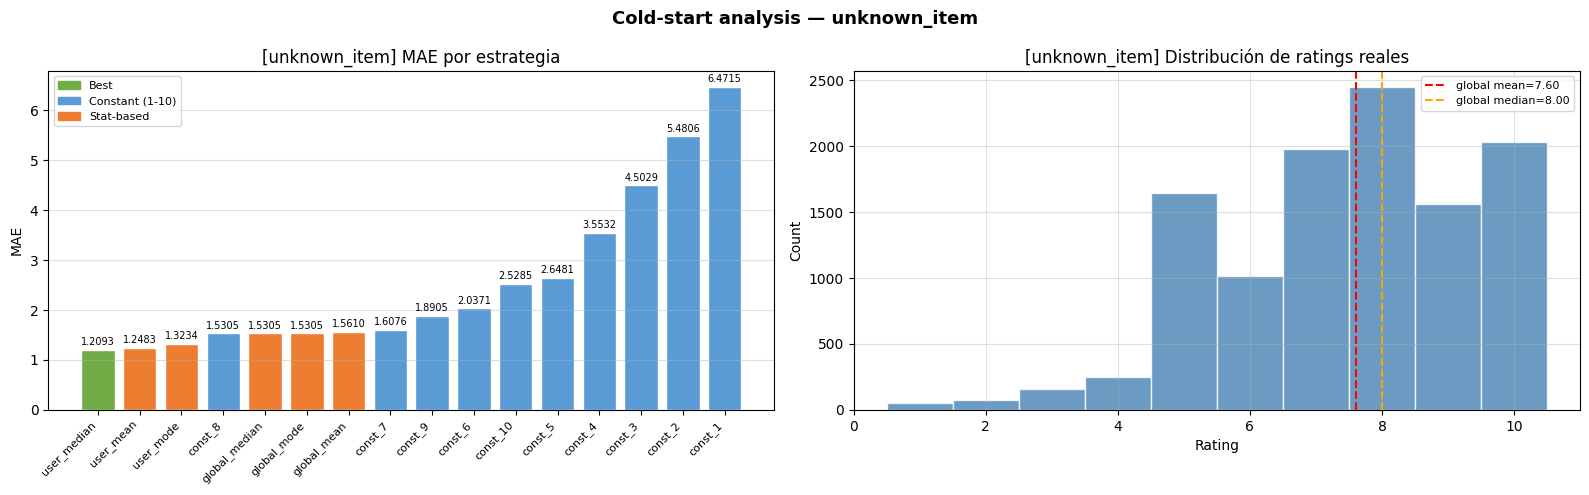


── both_unknown (n=1317) ──────────────────────────────
     strategy      mae
      const_7 1.589977
  global_mean 1.597782
global_median 1.602885
      const_8 1.602885
  global_mode 1.602885
      const_6 1.971906
      const_9 2.053151
      const_5 2.566439
     const_10 2.723614
      const_4 3.423690
      const_3 4.341686
      const_2 5.294609
      const_1 6.276386
  → Mejor estrategia: const_7 (MAE=1.5900)


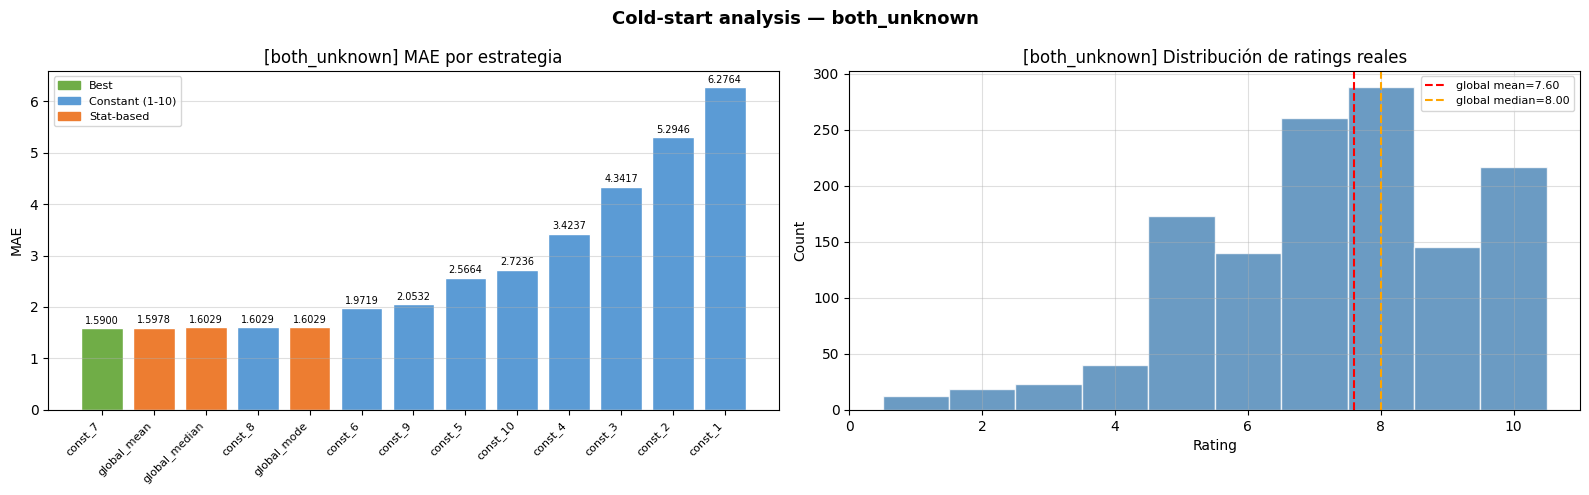

In [56]:
best_strategies, user_stats, item_stats, global_mean = analyze_coldstart(
    x_train, y_train, x_val, y_val, user_map, item_map
)

In [63]:
pmf_params = dict(
    n_factors   = 20,
    lambda_U    = 1,  lambda_V  = 1,
    lambda_bu   = 0.1, lambda_bi = 0.1,
    lr          = 0.005, n_epochs = 200,
    batch_size  = 256, optimizer = 'sgd',
    use_biases  = True, huber_delta = 1.0,
    log_every   = 5
)
ensemble_info = train_pmf_ensemble(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    pmf_params, n_models=5,
    seeds=[42, 7, 123, 999, 2024]
)


════════════════════════════════════════════════════════════
  Modelo 1/5  —  seed=42
════════════════════════════════════════════════════════════
 Epoch   Tr Huber    Tr MAE    Tr RMSE   Va Huber    Va MAE    Va RMSE        Status
─────────────────────────────────────────────────────────────────────────────────────
     5     0.8673    1.2806     1.6633     0.8814    1.2998     1.6681        ✔ best
    10     0.8099    1.2155     1.6039     0.8470    1.2609     1.6360        ✔ best
    15     0.7727    1.1730     1.5638     0.8293    1.2407     1.6193        ✔ best
    20     0.7446    1.1409     1.5323     0.8184    1.2286     1.6086        ✔ best
    25     0.7216    1.1146     1.5063     0.8112    1.2206     1.6015        ✔ best
    30     0.7020    1.0920     1.4839     0.8061    1.2150     1.5965        ✔ best
    35     0.6850    1.0726     1.4640     0.8024    1.2110     1.5927        ✔ best
    40     0.6698    1.0549     1.4461     0.7998    1.2081     1.5901        ✔ best
 

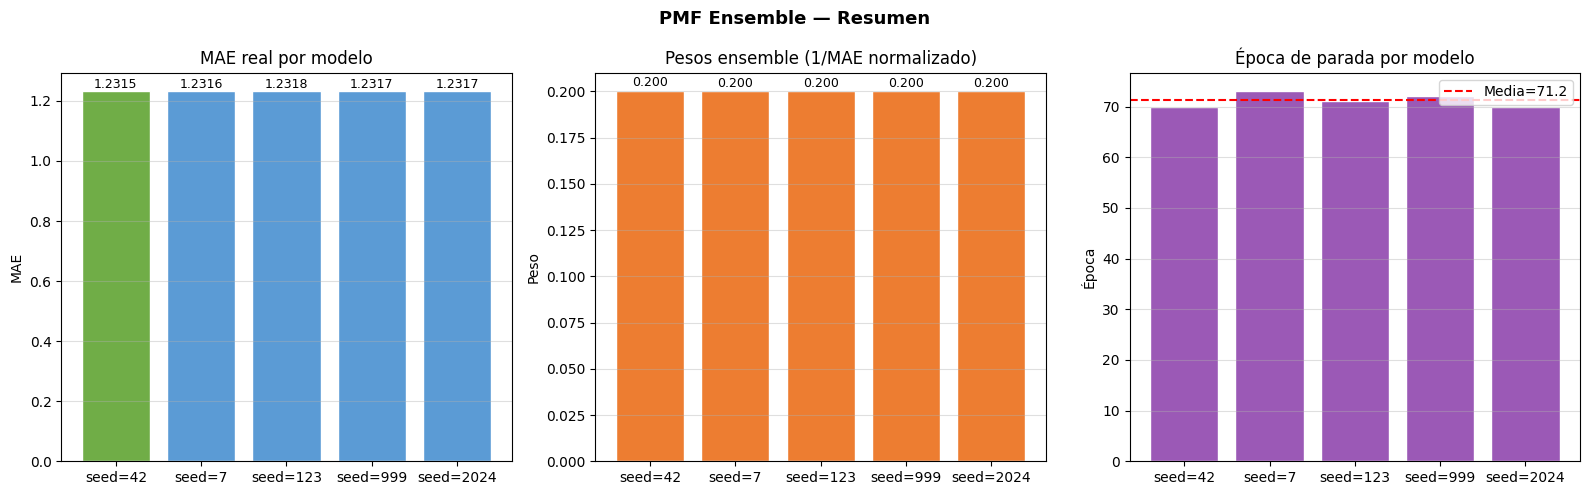

In [64]:
plot_ensemble_summary(ensemble_info)

In [65]:
val_preds_ensemble = weighted_predict(
    ensemble_info, x_val, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=False
)
mae_ensemble = np.mean(np.abs(val_preds_ensemble - y_val.values))
print(f"\nMAE ensemble (val): {mae_ensemble:.4f}")


Pesos del ensemble:
  seed=42  MAE=1.2315  peso=0.2000
  seed=7  MAE=1.2316  peso=0.2000
  seed=123  MAE=1.2318  peso=0.2000
  seed=999  MAE=1.2317  peso=0.2000
  seed=2024  MAE=1.2317  peso=0.2000


Weighted predict: 100%|██████████| 39036/39036 [00:01<00:00, 19650.63it/s]


MAE ensemble (val): 1.2316


In [68]:
test_preds_ensemble = weighted_predict(
    ensemble_info, df_test, user_map, item_map,
    best_strategies, user_stats, item_stats, global_mean,
    has_id_col=True
)


Pesos del ensemble:
  seed=42  MAE=1.2315  peso=0.2000
  seed=7  MAE=1.2316  peso=0.2000
  seed=123  MAE=1.2318  peso=0.2000
  seed=999  MAE=1.2317  peso=0.2000
  seed=2024  MAE=1.2317  peso=0.2000


Weighted predict: 100%|██████████| 43320/43320 [00:02<00:00, 19413.38it/s]


In [69]:
test_preds_ensemble.to_csv('submission_ensemble_pmf.csv', index=False)


In [ ]:
full_ensemble_info, user_map_full, item_map_full, global_mean_full = train_full_ensemble(
    x_train, y_train, x_val, y_val,
    ensemble_info, pmf_params,
    best_strategies, user_stats, item_stats,
    seeds=[42, 7, 123, 999, 2024]
)

# ── PASO 6: Predicciones finales test ────────────────────────────────────────
submission = weighted_predict(
    full_ensemble_info, x_test, user_map_full, item_map_full,
    best_strategies, user_stats, item_stats, global_mean_full,
    has_id_col=True
)
submission.to_csv('submission_ensemble_pmf.csv', index=False)
print(f"\nSubmission guardado: {len(submission)} predicciones")